# Counterfactual corrective BC: SACSoN -> TrajectoryCrafter warps -> ViNT policy

Combines `01_mbra_reannotate_and_embed.ipynb` (MBRA relabelling) and the
counterfactual idea from `02_counterfactual_generation.ipynb`. The
drift-then-recover history frames are produced by
[**TrajectoryCrafter**](https://github.com/TrajectoryCrafter/TrajectoryCrafter):
per window we estimate depth (DepthCrafter), forward-warp the **real** history
frames onto a perturbed camera path, and refine / fill disocclusions with its
CogVideoX-Fun-5B video-diffusion stage. The counterfactual frames are therefore
grounded in the real scene geometry (not a learned world model).

Pipeline per trajectory:
1. **MBRA relabel** every frame -> `(v, omega)`; `dt` pinned from the real `position`
   path length (the HDF5 group attrs carry real `position` + `yaw`).
2. For each window: `perturb_track` shifts the path with the paper's sine
   perturbation profile (peak mid-window, decaying to 0 by the window's end) and
   TrajectoryCrafter renders the drifted history frames along that camera path.
3. Save **both** a `nominal` sample (real frames -> real waypoints) and a
   `counterfactual` sample (warped+refined frames -> recovery waypoints).
4. Samples are pushed to an **HF dataset repo** (`DATA_REPO`) -- the data is kept.
5. A **ViNT policy is trained from scratch** on the accumulated samples and
   pushed to an **HF model repo** (`REPO_NAME`).

A Drive manifest tracks processed trajectories so generation + training span
sessions. SACSoN frames are 120x160 and get upscaled for the renderer, so expect
some softness / hallucinated detail in the disoccluded regions.


## 1. Setup

In [1]:
# Colab.
!pip install -q "efficientnet-pytorch==0.7.1" "huggingface_hub>=0.24" h5py opencv-python-headless pyyaml safetensors diffusers einops timm python-dotenv
!nvidia-smi


import argparse
import gc
import glob
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict

# Avoid hf_xet's process-global Rust tracing subscriber in reused Colab kernels.
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import yaml
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

from google.colab import drive
drive.mount("/content/drive")

MBRA_REPO = "/content/Learning-to-Drive-Anywhere-with-MBRA"
if not os.path.exists(MBRA_REPO):
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/vaishnavi-suresh/Learning-to-Drive-Anywhere-with-MBRA.git", MBRA_REPO], check=True)
sys.path.insert(0, os.path.join(MBRA_REPO, "train"))

# TrajectoryCrafter. NB: its DepthCrafter submodule is pinned to an ssh:// URL that
# Colab can't fetch -- rewrite github ssh -> https so --recursive / submodule update work.
subprocess.run(["git", "config", "--global", "url.https://github.com/.insteadOf", "git@github.com:"], check=False)
TC_REPO = "/content/TrajectoryCrafter"
_DC = os.path.join(TC_REPO, "DepthCrafter")
if not os.path.exists(TC_REPO):
    subprocess.run(["git", "clone", "-q", "--recursive",
                    "https://github.com/TrajectoryCrafter/TrajectoryCrafter.git", TC_REPO], check=True)
subprocess.run(["git", "-C", TC_REPO, "submodule", "sync", "-q"], check=False)
subprocess.run(["git", "-C", TC_REPO, "submodule", "update", "--init", "--recursive", "-q"], check=False)
if not os.path.exists(os.path.join(_DC, "depthcrafter", "depth_crafter_ppl.py")):
    shutil.rmtree(_DC, ignore_errors=True)
    subprocess.run(["git", "clone", "-q", "https://github.com/Tencent/DepthCrafter.git", _DC], check=True)
open(os.path.join(_DC, "__init__.py"), "a").close()                       # make `DepthCrafter` an importable package
assert os.path.exists(os.path.join(_DC, "depthcrafter", "depth_crafter_ppl.py")), "DepthCrafter submodule missing"

# TC's requirements.txt pins torch==2.4.0 / deepspeed / gradio / decord etc. that
# break on Colab (Python 3.13, preinstalled torch). Install a filtered set instead.
_DROP = {"torch", "torchvision", "torchaudio", "xformers", "deepspeed", "gradio", "tensorboard",
         "decord", "openexr", "imath", "pyexr"}   # no py3.13 wheels / need system libs; unused by our path
_UNPIN = {"av", "transformers", "diffusers", "accelerate", "numpy", "pillow"}


def _req_line(raw):
    raw = raw.split("#")[0].strip()
    if not raw:
        return None
    name = raw.split("==")[0].split(">=")[0].split("<")[0].split("[")[0].strip().lower()
    if name in _DROP:
        return None
    if name in _UNPIN:
        extra = "[" + raw.split("[", 1)[1] if "[" in raw else ""
        return name + extra
    return raw


import importlib.util as _ilu

_TC_STAMP = os.path.join(TC_REPO, ".deps_installed")
if not os.path.exists(_TC_STAMP):
    _reqs = []
    for _f in (os.path.join(TC_REPO, "requirements.txt"), os.path.join(_DC, "requirements.txt")):
        if os.path.exists(_f):
            _reqs += [x for x in (_req_line(l) for l in open(_f)) if x]
    _reqs = list(dict.fromkeys(_reqs + ["av", "imageio[ffmpeg]", "kornia", "scikit-image"]))
    _r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_reqs], capture_output=True, text=True)
    if _r.returncode:
        print("batch install failed; retrying package-by-package (failures skipped)...")
        _bad = [p for p in _reqs
                if subprocess.run([sys.executable, "-m", "pip", "install", "-q", p],
                                  capture_output=True, text=True).returncode]
        if _bad:
            print("could not install (non-fatal unless needed below):", _bad)
    _need = ["diffusers", "transformers", "accelerate", "omegaconf", "einops",
             "kornia", "av", "imageio", "safetensors", "timm"]
    _missing = [m for m in _need if _ilu.find_spec(m) is None]
    if _missing:
        raise RuntimeError("required packages still missing after install: %s -- pip logs above" % _missing)
    open(_TC_STAMP, "w").close()
    print("TrajectoryCrafter deps installed -- if imports fail below, restart the runtime and re-run this cell.")

try:
    import decord as _decmod  # noqa
    _decmod.VideoReader
    _have_decord = True
except Exception:
    _have_decord = False
if not _have_decord:                                 # no decord wheels for Python 3.13 -- shim the API TC uses
    open(os.path.join(TC_REPO, "decord.py"), "w").write(
        "import numpy as np, imageio.v3 as _iio, cv2 as _cv2\n"
        "class _Batch:\n"
        "    def __init__(self, a): self._a = np.asarray(a)\n"
        "    def asnumpy(self): return self._a\n"
        "    @property\n"
        "    def shape(self): return self._a.shape\n"
        "class VideoReader:\n"
        "    def __init__(self, path, ctx=None, width=None, height=None, **kw):\n"
        "        v = np.asarray(_iio.imread(path, plugin='pyav'))\n"
        "        if width and height:\n"
        "            v = np.stack([_cv2.resize(f, (width, height)) for f in v])\n"
        "        self._v = v\n"
        "    def __len__(self): return len(self._v)\n"
        "    def get_batch(self, idx): return _Batch(self._v[np.asarray(list(idx))])\n"
        "def cpu(*a, **k): return None\n"
        "def gpu(*a, **k): return None\n")
    print("decord shim written to", os.path.join(TC_REPO, "decord.py"))
sys.path.insert(0, TC_REPO)

# TrajectoryCrafter's vendored CogVideoX code hits diffusers APIs that diffusers >= 0.33
# turned into hard errors via deprecate(). Soften "already past removal" ValueErrors to
# no-ops. reload() first so this is idempotent even if a prior (broken) patch is live.
import importlib  # noqa: E402
import diffusers  # noqa: E402
import diffusers.utils.deprecation_utils as _du  # noqa: E402
_du = importlib.reload(_du)                     # restore the pristine deprecate()
_TRUE_DEPRECATE = _du.deprecate


def _deprecate_soft(*a, **k):
    try:
        return _TRUE_DEPRECATE(*a, **k)
    except ValueError as _e:
        if "should be removed since diffusers" not in str(_e):
            raise


_du.deprecate = _deprecate_soft
diffusers.utils.deprecate = _deprecate_soft
for _n, _m in list(sys.modules.items()):
    if _n.startswith("diffusers") and hasattr(_m, "deprecate"):
        try:
            _m.deprecate = _deprecate_soft
        except Exception:
            pass
print("diffusers", diffusers.__version__, "(deprecate() softened for TrajectoryCrafter)")

# Colab's torchvision has no video backend -> shim write_video (used by TC's save_video).
import torchvision  # noqa: E402
import torchvision.io as _tvio  # noqa: E402
_wv = getattr(_tvio, "write_video", None)
if _wv is None or not str(getattr(_wv, "__module__", "")).startswith("torchvision"):
    import imageio.v2 as _iio2  # noqa: E402

    def _write_video(filename, video_array, fps, video_codec="h264", options=None, **_kw):
        v = video_array.detach().cpu().numpy() if hasattr(video_array, "detach") else np.asarray(video_array)
        if v.dtype != np.uint8:
            v = (np.clip(v, 0, 1) * 255).astype(np.uint8) if float(np.nanmax(v)) <= 1.5 else np.clip(v, 0, 255).astype(np.uint8)
        v = np.ascontiguousarray(v)
        with _iio2.get_writer(filename, format="FFMPEG", mode="I", fps=float(fps),
                              codec="libx264", macro_block_size=1, pixelformat="yuv420p") as _w:
            for _f in v:
                _w.append_data(_f)

    _write_video._tc_shim = True
    _tvio.write_video = _write_video
    print("torchvision.io.write_video shimmed (imageio-ffmpeg)")

from vint_train.models.exaug.exaug import ExAug_dist_delay  # noqa: F401  (prereq check)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu"
GPU_MEM_GB = (torch.cuda.get_device_properties(0).total_memory / 1e9) if device.type == "cuda" else 0.0
cv2.setNumThreads(max(1, os.cpu_count() or 2))
torch.backends.cudnn.benchmark = True
if device.type == "cuda":
    _free, _tot = (x / 1e9 for x in torch.cuda.mem_get_info())
    print("device:", device, "|", GPU_NAME, "| %.0f GB total, %.1f GB free" % (_tot, _free))
    if _free < 20:
        print("!! low free VRAM -- the GPU is shared/occupied. `nvidia-smi` and kill stale PIDs, or restart.")
else:
    print("device: cpu")

Wed Sep 30 01:46:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   40C    P0             66W /  400W |   15038MiB /  81920MiB |     12%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Config

In [2]:
# --- Dataset ---
HF_DATASET = "konpat/huron-sacson-hdf5"
H5_FILE = "sacson.h5"
MAX_TRAJ = None          # None = whole /train split (~2067). Resumable via the Drive manifest.
N_VAL_TRAJ = 320         # /test trajectories reserved for validation -- was 80 (only ~248 val
                         # samples, noisy at the ~0.01-0.02 checkpoint-ranking resolution we
                         # need). Standard error scales as 1/sqrt(n), so resolving that noise
                         # needs ~4x the samples, not 2x -- hence 320, not 160. The dataset's
                         # raw /test split lists 612 trajectory names (data_splits/test/
                         # traj_names.txt on HF), so this comfortably fits even after the same
                         # ~15% attrition seen on /train (2441 listed -> ~2067 usable). Slicing
                         # is safe either way (list[:N_VAL_TRAJ] just clamps if fewer exist).
SAMPLE_STRIDE = 5        # overlapping window stride (frames)
MAX_SAMPLES_PER_TRAJ = 8        # each counterfactual clip is a full CogVideoX-Fun pass -- keep low.
                         # Was 3: nominal/counterfactual pairs from the same window share nearly
                         # the same context + goal, so 3 windows/traj gave little independent
                         # diversity relative to model capacity (2x EfficientNet-b0 + a 4-layer
                         # transformer decoder, ~10M+ params). Pushed to 8 (~2.7x the original 3,
                         # so ~2.7x this stage's generation compute too, since cost is roughly
                         # linear in samples/traj) -- this alone won't fix the capacity/data
                         # mismatch (still low-thousands of independent windows against a 10M+
                         # param model), so it's a secondary lever; early stopping above is the
                         # primary fix. Raise further only if you have GPU budget to spare.
METRIC_WAYPOINT_SPACING = 0.255   # sacson value from vint_train/data/data_config.yaml (reference: expected median step)
CALIBRATE_DT_FROM_POSITION = True
SACSON_FPS = 3.0                  # fallback dt = 1/SACSON_FPS

# --- MBRA (fixed by the checkpoint) ---
CONTEXT_SIZE = 5
LEN_TRAJ_PRED = 8
ROBOT_SIZE, DELAY = 0.3, 0.0
VEL_PAST_LINEAR, VEL_PAST_ANGULAR = 0.5, 0.0

# --- Counterfactual window ---
TH_HISTORY = 20          # history frames in a window (obs = last CONTEXT_SIZE+1 of these)
T_FUTURE = 30            # recovery frames after t
WINDOW_N = TH_HISTORY + T_FUTURE
# GOAL_HORIZON was a fixed 15 -- every sample paired the observation with a goal EXACTLY 15
# frames ahead, so `dist` (saved as this same constant every time) had zero variation for the
# model to learn from; its distance head just converged to predicting ~15 regardless of input.
# Sampled as a variable per-window range instead so `dist` becomes a real, learnable label.
GOAL_HORIZON_MIN = 5     # closest the goal image may be sampled (frames past t)
GOAL_HORIZON_MAX = 25    # farthest the goal image may be sampled (frames past t); must stay
                         # < T_FUTURE so the window (already built out to T_FUTURE) covers it
MBRA_GOAL_HORIZON = 15   # unrelated: fixed horizon the pretrained MBRA relabelling model itself
                         # expects (its own checkpoint) -- not touched by the dist-label fix above
PERTURBATION_LEVELS = {"mild": 0.15, "strong": 0.35}   # alpha: peak lateral/longitudinal displacement (m)

# --- TrajectoryCrafter (geometry forward-warp + CogVideoX-Fun refinement) ---
TC_CLIP_LEN = 17          # real frames per counterfactual clip; must be 4k+1 (CogVideoX-Fun latent stride)
TC_SAMPLE_SIZE = (384, 512)   # (H, W) the diffusion runs at; downsampled to IMAGE_SIZE for the saved sample
TC_DIFFUSION_STEPS = 30
TC_LOW_VRAM = False       # True = sequential CPU offload (lower peak but breaks CogVideoX-Fun: meta-tensor error). Keep False; free GPU mem / shrink TC_SAMPLE_SIZE if OOM.
TC_GUIDANCE = 6.0
TC_DEPTH_STEPS = 5
TC_SEED = 43
TC_NEAR, TC_FAR = 0.01, 100.0
TC_MODEL_NAME = "alibaba-pai/CogVideoX-Fun-V1.1-5b-InP"
TC_TRANSFORMER = "TrajectoryCrafter/TrajectoryCrafter"
TC_POSE_W2C = False       # forward_warp pose convention: False = camera-to-world (see tc_probe())
TC_DEPTH_SIGN = "auto"    # "auto" | "depth" | "disparity" -- DepthCrafter output sign (auto: fit to the ground plane)
TC_SUPERSAMPLE = 2        # render poses at Nx the frame rate (nearest real frame per step) -> smoother drift
TC_PROMPT = ("a first-person view from a mobile robot driving forward through an "
             "indoor space, smooth steady camera motion, photorealistic")
TC_NEG_PROMPT = ("The video is not of a high quality, it has a low resolution. "
                 "Watermark present in each frame. Strange motion trajectory. ")

# --- Camera: HuRoN uses a ~170-deg FISHEYE. forward_warp assumes a pinhole, so we
#     remap fisheye -> pinhole (equidistant model) before the warp. Tune the two
#     FOVs with show_undistort() until straight lines come out straight.
TC_UNDISTORT = True
SACSON_FISHEYE_FOV_DEG = 170.0    # native fisheye horizontal FOV (equidistant r = f*theta)
SACSON_HFOV_DEG = 100.0           # pinhole HFOV kept after undistort (also the warp intrinsics)
CAMERA_HEIGHT_M = 0.5
CAMERA_FORWARD_OFFSET_M = 0.3

# --- ViNT policy / training ---
IMAGE_SIZE = (96, 96)
VINT_OBS_ENCODING_SIZE = 512
VINT_MHA = 4
BATCH_SIZE = 128
EPOCHS = 30              # was 80 -- val loss plateaued/bounced in a noisy 0.42-0.46 band from
                         # ~epoch 15-20 onward while train action loss kept dropping (0.58 ->
                         # 0.23); the cosine schedule now anneals over a realistic training
                         # length instead of spending most of its decay past the plateau.
                         # Paired with real early stopping (EARLY_STOP_PATIENCE) below.
LR = 3e-4
WEIGHT_DECAY = 3e-4      # was 1e-4 -- bumped as a secondary regularizer alongside early stopping
                         # below; train action loss kept dropping ~2.5x past where val loss
                         # plateaued, a classic overfitting signature.
WARMUP_EPOCHS = 4
ALPHA = 0.5
EARLY_STOP_PATIENCE = 8  # stop if val loss hasn't improved by more than MIN_DELTA (see the
                         # training loop) for this many epochs, instead of always training to
                         # EPOCHS and picking whichever epoch's noisy val number was lowest
WAYPOINT_SCALE = 1.0
AUG = True
USE_AMP = True

# --- Paths / publishing ---
DRIVE_ROOT = "/content/drive/MyDrive/sacson_nwm_bc"
TC_HF_CACHE = os.path.join(DRIVE_ROOT, "hf_cache")   # persist the ~35 GB of TrajectoryCrafter / DepthCrafter / CogVideoX weights
os.environ["HF_HOME"] = TC_HF_CACHE
CACHE_DIR = "/content/bc_cache"                 # local working copy of the sample cache
MANIFEST_PATH = os.path.join(DRIVE_ROOT, "processed_manifest.json")
CKPT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
CLIP_DIR = os.path.join(DRIVE_ROOT, "counterfactual_clips")
SAVE_CLIPS_FOR_FIRST_N = 10
DATA_REPO = "vint-sacson-bc-data"              # HF dataset repo (samples are pushed here, kept)
REPO_NAME = "vint-sacson-corrective"           # HF model repo
PUSH_DATA_EVERY = 20                            # push new npz to the HF dataset repo every N trajectories
RESUME_FROM_HF = True
SEED = 0

for d in (DRIVE_ROOT, TC_HF_CACHE, CACHE_DIR, CKPT_DIR, CLIP_DIR,
          os.path.join(CACHE_DIR, "train"), os.path.join(CACHE_DIR, "test")):
    os.makedirs(d, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- HF token: env var -> .env (same machine only) -> interactive prompt -> verify ---
ENV_FILE = ""          # optional: absolute path to a .env ON THIS MACHINE (Colab != your laptop)
from dotenv import load_dotenv, find_dotenv
from huggingface_hub import HfApi
import getpass


def _clean_tok():
    return (os.environ.get("HF_TOKEN") or "").strip().strip("'\"")


if not _clean_tok():
    _p = ENV_FILE or find_dotenv(usecwd=True)
    if _p and os.path.exists(_p):
        load_dotenv(_p, override=True)
        print("dotenv:", _p)

while True:
    tok = _clean_tok()
    if not tok:
        tok = getpass.getpass("Paste your Hugging Face token (write scope, hidden): ").strip()
    os.environ["HF_TOKEN"] = tok
    try:
        HF_USER = HfApi().whoami(token=tok)["name"]
        print("HF logged in as:", HF_USER)
        break
    except Exception as e:
        print("token rejected (%s) -- try again" % type(e).__name__)
        os.environ.pop("HF_TOKEN", None)


def load_hf_token():
    tok = _clean_tok()
    if not tok:
        raise RuntimeError("HF_TOKEN not set -- rerun the Section 2 config cell (it will prompt).")
    return tok


assert (TC_CLIP_LEN - 1) % 4 == 0 and TC_CLIP_LEN >= CONTEXT_SIZE + 1 and TC_CLIP_LEN <= TH_HISTORY
print("TC clip:", TC_CLIP_LEN, "| diffusion steps:", TC_DIFFUSION_STEPS,
      "| window:", WINDOW_N,
      "| min traj length:", CONTEXT_SIZE + (TH_HISTORY - 1) + max(T_FUTURE, GOAL_HORIZON_MAX) + 2)

HF logged in as: vaishsuresh32
TC clip: 17 | diffusion steps: 30 | window: 50 | min traj length: 56


In [3]:
# TrajectoryCrafter's Warper.forward_warp expects world-to-camera extrinsics.
# It computes T_target @ inverse(T_source), so camera-to-world poses invert the relative motion.
TC_POSE_W2C = True

## 2b. Smoke-test TrajectoryCrafter on one video

Runs the **full** pipeline (DepthCrafter -> forward-warp -> CogVideoX-Fun) on the
repo's bundled `p7.mp4` with a stock camera move, before wiring it to SACSoN.
This is where the ~35 GB of weights download (cached to Drive via `HF_HOME`).
It uses a **throwaway** model instance -- TrajectoryCrafter's `infer_*` methods
free their sub-models on exit -- so Section 5 loads the production one afresh
(fast, from the warm cache).


In [4]:
# TrajectoryCrafter's modules assume the repo root is the cwd
_TC_CWD = os.getcwd()
os.chdir(TC_REPO)
from demo import TrajCrafter


def make_tc_opts():
    """argparse.Namespace with every field TrajectoryCrafter's inference.py defines
    (so pvd.infer_* also work), plus our overrides."""
    o = argparse.Namespace(
        video_path=None, out_dir="/content/tc_out", device=str(device), exp_name="run",
        seed=TC_SEED, video_length=49, fps=10, stride=2, server_name=None,   # video_length: TC infer_* native; production sets num_frames itself
        radius_scale=1.0, camera="target", mode="direct", mask=True, traj_txt=None, target_pose=None,
        near=TC_NEAR, far=TC_FAR, anchor_idx=0, low_gpu_memory_mode=TC_LOW_VRAM,
        model_name=TC_MODEL_NAME, sampler_name="DDIM_Origin", transformer_path=TC_TRANSFORMER,
        sample_size=list(TC_SAMPLE_SIZE), diffusion_guidance_scale=TC_GUIDANCE,
        diffusion_inference_steps=TC_DIFFUSION_STEPS, prompt=None,
        negative_prompt=TC_NEG_PROMPT,
        refine_prompt=". Photorealistic, consistent with the input frames, unchanged background.",
        blip_path="Salesforce/blip2-opt-2.7b", unet_path="tencent/DepthCrafter",
        pre_train_path="stabilityai/stable-video-diffusion-img2vid-xt",
        cpu_offload="sequential" if TC_LOW_VRAM else "model",
        depth_inference_steps=TC_DEPTH_STEPS, depth_guidance_scale=1.0,
        window_size=110, overlap=25, max_res=1024, weight_dtype=torch.bfloat16)
    return o


RUN_SMOKE_TEST = True
try:
    if RUN_SMOKE_TEST:
        _pvd = TrajCrafter(make_tc_opts())
        for _fn in ("enable_slicing", "enable_tiling"):
            try:
                getattr(_pvd.pipeline.vae, _fn)()
            except Exception:
                pass
        _s = make_tc_opts()
        _s.video_path = os.path.join(TC_REPO, "test", "videos", "p7.mp4")
        _s.traj_txt = os.path.join(TC_REPO, "test", "trajs", "loop2.txt")
        _s.camera, _s.mode = "target", "direct"
        _s.target_pose = [0.0, -20.0, 0.3, 0.0, 0.0]
        _s.video_length = 25
        _s.out_dir, _s.exp_name = "/content/tc_smoke", "p7"
        _s.save_dir = os.path.join(_s.out_dir, _s.exp_name)
        os.makedirs(_s.save_dir, exist_ok=True)
        _pvd.infer_direct(_s)
        del _pvd
        gc.collect(); torch.cuda.empty_cache()
        from IPython.display import Video, display
        for _n in ("input", "render", "gen"):
            _p = os.path.join(_s.save_dir, _n + ".mp4")
            if os.path.exists(_p):
                print(_n); display(Video(_p, embed=True, width=384))
finally:
    os.chdir(_TC_CWD)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/tmp/ipykernel_228854/1395714951.py:144: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  return _TRUE_DEPRECATE(*a, **k)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers
Xformers is not enabled


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 3. Fetch the HDF5, inspect schema, helpers

The trajectory group attrs carry `num_frames`, real `position` (N,2) metres, real
`yaw` (N,) rad, `trajectory_name`. Frames are vlen JPEG bytes (~120×160).

In [5]:
from huggingface_hub import hf_hub_download

H5_PATH = hf_hub_download(HF_DATASET, H5_FILE, repo_type="dataset", token=load_hf_token())
print("hdf5:", H5_PATH, "(%.2f GB)" % (os.path.getsize(H5_PATH) / 1e9))

_h5 = h5py.File(H5_PATH, "r")
print("groups:", list(_h5.keys()))
for split in [s for s in ("train", "test") if s in _h5]:
    keys = list(_h5[split].keys())
    node = _h5[split][keys[0]]
    print("/%s: %d trajectories | sample %r" % (split, len(keys), keys[0]))
    if isinstance(node, h5py.Group):
        for name, item in node.items():
            print("   %s: %s %s" % (name, getattr(item, "shape", None), getattr(item, "dtype", "")))
        print("   attr keys:", list(node.attrs))


def _decode_jpeg(buf):
    b = buf.tobytes() if hasattr(buf, "tobytes") else bytes(buf)
    img = cv2.imdecode(np.frombuffer(b, np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("cv2.imdecode returned None")
    return img


def load_traj(split, key):
    node = _h5[split][key]
    raw = node["frames"][()] if isinstance(node, h5py.Group) else node[()]
    return [_decode_jpeg(b) for b in raw]


def traj_odom(split, key):
    a = _h5[split][key].attrs
    return np.asarray(a["position"], dtype=np.float64), np.asarray(a["yaw"], dtype=np.float64)


def wrap_pi(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


_p = load_traj("train", list(_h5["train"].keys())[0])
_pp, _py = traj_odom("train", list(_h5["train"].keys())[0])
print("load_traj: %d frames %s | odom: pos %s yaw %s" % (len(_p), _p[0].shape, _pp.shape, _py.shape))

hdf5: /root/.cache/huggingface/hub/datasets--konpat--huron-sacson-hdf5/snapshots/fbfc29101ec3cf331e9fca4c5d5a8d61815a874d/sacson.h5 (1.00 GB)
groups: ['test', 'train']
/train: 2067 trajectories | sample 'Dec-06-2022-bww8_00000000_0'
   frames: (387,) object
   attr keys: ['num_frames', 'position', 'trajectory_name', 'yaw']
/test: 515 trajectories | sample 'Dec-06-2022-bww8_00000002_0'
   frames: (72,) object
   attr keys: ['num_frames', 'position', 'trajectory_name', 'yaw']
load_traj: 387 frames (120, 160, 3) | odom: pos (387, 2) yaw (387,)


## 4. MBRA model + `label_traj`

In [6]:
with open(os.path.join(MBRA_REPO, "train", "config", "MBRA.yaml")) as f:
    mbra_config = yaml.safe_load(f)
assert mbra_config["context_size"] == CONTEXT_SIZE and mbra_config["len_traj_pred"] == LEN_TRAJ_PRED

mbra = ExAug_dist_delay(
    context_size=mbra_config["context_size"], len_traj_pred=mbra_config["len_traj_pred"],
    learn_angle=mbra_config["learn_angle"], obs_encoder=mbra_config["obs_encoder"],
    obs_encoding_size=mbra_config["obs_encoding_size"], late_fusion=mbra_config["late_fusion"],
    mha_num_attention_heads=mbra_config["mha_num_attention_heads"],
    mha_num_attention_layers=mbra_config["mha_num_attention_layers"],
    mha_ff_dim_factor=mbra_config["mha_ff_dim_factor"])
_w = os.path.join(MBRA_REPO, "deployment", "mbra.pth")
if not os.path.exists(_w):
    os.makedirs(os.path.dirname(_w), exist_ok=True)
    shutil.copy(hf_hub_download("NHirose/MBRA_project_models", "mbra.pth"), _w)
_miss, _ = mbra.load_state_dict(torch.load(_w, map_location=device), strict=False)
assert not _miss, "missing MBRA keys: %s" % _miss
mbra.eval().to(device)

frame_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])


def to_rgb(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def frame_tensor(bgr):
    return frame_transform(Image.fromarray(to_rgb(bgr)))


_robot_size = ROBOT_SIZE * torch.ones(1, 1, 1, device=device)
_delay = DELAY * torch.ones(1, 1, 1, device=device)
_vel_past = torch.cat([VEL_PAST_LINEAR * torch.ones(1, 6),
                       VEL_PAST_ANGULAR * torch.ones(1, 6)], dim=1).unsqueeze(2).to(device)


def integrate_poses(v, w, dt):
    """MBRA (v, omega) + per-step dt -> (x, y, theta) dead-reckoned track."""
    n = len(v)
    poses = np.zeros((n, 3))
    x = y = th = 0.0
    for i in range(n):
        th += w[i] * dt[i]
        x += v[i] * math.cos(th) * dt[i]
        y += v[i] * math.sin(th) * dt[i]
        poses[i] = (x, y, th)
    return poses


def label_traj(split, key):
    frames = load_traj(split, key)
    n = len(frames)
    if n < CONTEXT_SIZE + (TH_HISTORY - 1) + max(T_FUTURE, GOAL_HORIZON_MAX) + 2:
        return None
    ftens = [frame_tensor(f) for f in frames]
    hi = n - max(T_FUTURE, GOAL_HORIZON_MAX) - 1
    rows = []
    for t in range(CONTEXT_SIZE, hi):
        obs = torch.cat(ftens[t - CONTEXT_SIZE:t + 1], dim=0).unsqueeze(0).to(device)
        goal = ftens[min(t + MBRA_GOAL_HORIZON, n - 1)].unsqueeze(0).to(device)
        with torch.no_grad():
            lin, ang, _ = mbra(obs, goal, _robot_size, _delay, _vel_past)
        rows.append({"frame_id": t, "v": float(lin[0, 0]), "w": float(ang[0, 0])})
    if len(rows) < WINDOW_N:
        return None
    df = pd.DataFrame(rows)
    fids = df["frame_id"].to_numpy()
    sum_v = float(np.abs(df["v"]).sum())
    if CALIBRATE_DT_FROM_POSITION:
        pos, _ = traj_odom(split, key)
        path_len = float(np.hypot(*np.diff(pos[fids[0]:fids[-1] + 1], axis=0).T).sum())
        dt = float(np.clip(path_len / max(sum_v, 1e-6), 0.03, 3.0))
    else:
        dt = 1.0 / SACSON_FPS
    v = df["v"].to_numpy(); w = df["w"].to_numpy()
    poses = integrate_poses(v, w, np.full(len(df), dt))
    med_step = float(np.median(np.abs(v))) * dt
    return frames, fids, v, w, dt, poses, med_step

/content/Learning-to-Drive-Anywhere-with-MBRA/train/vint_train/models/vint/self_attention.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sa_decoder = nn.TransformerEncoder(self.sa_layer, num_layers=num_layers)


## 5. Load TrajectoryCrafter (production instance)

Builds the persistent `pvd = TrajCrafter(...)` used by every window: DepthCrafter
(`pvd.depth_estimater`), the point-cloud forward-warp (`pvd.funwarp`) and the
CogVideoX-Fun refinement pipeline (`pvd.pipeline`). BLIP2 is dropped -- we pass a
fixed prompt (`TC_PROMPT`).


In [6]:
_TC_CWD = os.getcwd(); os.chdir(TC_REPO)
try:
    from demo import TrajCrafter
    TC_OPTS = make_tc_opts()
    if "pvd" not in globals():
        pvd = TrajCrafter(TC_OPTS)
        for _a in ("captioner", "caption_processor"):
            if hasattr(pvd, _a):
                delattr(pvd, _a)
        for _fn in ("enable_slicing", "enable_tiling"):   # cut VAE decode VRAM
            try:
                getattr(pvd.pipeline.vae, _fn)()
            except Exception:
                pass
        gc.collect(); torch.cuda.empty_cache()
finally:
    os.chdir(_TC_CWD)

TC_VER = "tc-v1  depthcrafter + forward_warp + cogvideox-fun-5b"
print("TrajectoryCrafter loaded [%s]\n  sample_size=%s | clip_len=%d | steps=%d | guidance=%.1f"
      % (TC_VER, TC_SAMPLE_SIZE, TC_CLIP_LEN, TC_DIFFUSION_STEPS, TC_GUIDANCE))


/tmp/ipykernel_8459/1395714951.py:144: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  return _TRUE_DEPRECATE(*a, **k)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers
Xformers is not enabled


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Expected types for vae: (<class 'diffusers.models.autoencoders.autoencoder_kl_cogvideox.AutoencoderKLCogVideoX'>,), got <class 'models.autoencoder_magvit.AutoencoderKLCogVideoX'>.


TrajectoryCrafter loaded [tc-v1  depthcrafter + forward_warp + cogvideox-fun-5b]
  sample_size=(384, 512) | clip_len=17 | steps=30 | guidance=6.0


## 6. Perturbation, camera geometry, warp + refine

`perturb_track` makes the drift-then-recover `pert_track` from the paper's sine
perturbation profile. `world_from_cam` maps a
robot `(x, y, theta)` to a 4x4 camera pose (nb 02's OpenCV extrinsic; c2w unless
`TC_POSE_W2C`). `metric_depth` turns DepthCrafter's raw output into metric z-depth
-- it auto-detects disparity vs depth by fitting the analytic ground plane
(`CAMERA_HEIGHT_M`). `tc_render_refine` supersamples the pose pair by
`TC_SUPERSAMPLE`, warps the nearest real frame onto each perturbed pose
(`pvd.funwarp.forward_warp`), then CogVideoX-Fun refines the `TC_RENDER_LEN` clip.
Use `tc_probe()` in Section 8b to check the pose / depth conventions.


In [7]:
def perturb_track(poses, alpha):
    """poses (WINDOW_N,3) x,y,theta -> perturbed track using the paper's shared
    sine perturbation profile (Sec. III-C, "Corrective behavior expansions"):
        ΔT(τ) = alpha * sin(pi * τ / (T_h + T))
    with τ the window index (0 at the first history frame, T_h+T-1 = WINDOW_N-1
    at the last future frame) and T_h + T = WINDOW_N. The SAME profile is what
    drifts the history off the real path and what shifts the future/original-expert
    trajectory into the recovery maneuver -- it decays back toward 0 by the end of
    the window. alpha sets the peak lateral/longitudinal displacement (m). The
    offset is applied perpendicular to the real heading; the perturbed heading is
    the tangent of the shifted path."""
    tau = np.arange(len(poses))
    e = alpha * np.sin(np.pi * tau / WINDOW_N)
    normal = np.stack([-np.sin(poses[:, 2]), np.cos(poses[:, 2])], axis=1)   # perp to real heading
    xy = poses[:, :2] + e[:, None] * normal
    d = np.diff(xy, axis=0)
    yaw_p = np.concatenate([np.arctan2(d[:, 1], d[:, 0]), poses[-1:, 2]])    # tangent of shifted path
    return np.concatenate([xy, yaw_p[:, None]], axis=1)


# --- camera model: SACSoN front view, OpenCV convention (x-right, y-down, z-forward) ---
_R_ROBOT_FROM_CAM = np.array([[0, 0, 1], [-1, 0, 0], [0, -1, 0]], dtype=np.float64)
_T_ROBOT_FROM_CAM = np.eye(4)
_T_ROBOT_FROM_CAM[:3, :3] = _R_ROBOT_FROM_CAM
_T_ROBOT_FROM_CAM[:3, 3] = [CAMERA_FORWARD_OFFSET_M, 0.0, CAMERA_HEIGHT_M]


def _pose_se2(x, y, theta):
    c, s = math.cos(theta), math.sin(theta)
    T = np.eye(4)
    T[:2, :2] = [[c, -s], [s, c]]
    T[0, 3], T[1, 3] = x, y
    return T


def world_from_cam(x, y, theta, w2c=None):
    """robot (x, y, theta) in the world plane -> 4x4 camera pose for forward_warp
    (camera-to-world; world-to-camera if w2c / TC_POSE_W2C)."""
    w2c = TC_POSE_W2C if w2c is None else w2c
    T = _pose_se2(x, y, theta) @ _T_ROBOT_FROM_CAM
    return np.linalg.inv(T) if w2c else T


def sacson_K(h, w, hfov_deg=None):
    hfov = math.radians(SACSON_HFOV_DEG if hfov_deg is None else hfov_deg)
    f = 0.5 * w / math.tan(0.5 * hfov)
    return np.array([[f, 0.0, 0.5 * w], [0.0, f, 0.5 * h], [0.0, 0.0, 1.0]], dtype=np.float64)


_UNDIST_MAPS = {}


def _undistort_maps(h, w):
    """remap LUT: equidistant fisheye (SACSON_FISHEYE_FOV_DEG) -> pinhole (SACSON_HFOV_DEG)."""
    key = (h, w, round(SACSON_FISHEYE_FOV_DEG, 2), round(SACSON_HFOV_DEG, 2))
    if key not in _UNDIST_MAPS:
        Kp = sacson_K(h, w)
        ff = 0.5 * w / math.radians(0.5 * SACSON_FISHEYE_FOV_DEG)     # fisheye focal px: r = ff * theta
        cx, cy = 0.5 * w, 0.5 * h
        uu, vv = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
        x = (uu - Kp[0, 2]) / Kp[0, 0]
        y = (vv - Kp[1, 2]) / Kp[1, 1]
        rp = np.sqrt(x * x + y * y)
        theta = np.arctan(rp)
        scale = np.where(rp > 1e-9, ff * theta / np.maximum(rp, 1e-9), ff)
        _UNDIST_MAPS[key] = ((cx + x * scale).astype(np.float32), (cy + y * scale).astype(np.float32))
    return _UNDIST_MAPS[key]


def undistort(rgb):
    """fisheye RGB -> pinhole RGB (same size). No-op when TC_UNDISTORT is False."""
    if not TC_UNDISTORT:
        return rgb
    h, w = rgb.shape[:2]
    mx, my = _undistort_maps(h, w)
    return cv2.remap(rgb, mx, my, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)


def _analytic_ground_depth(K, cam_h, h, w):
    """z-depth of the ground plane for a level camera at height cam_h (inf above the horizon)."""
    v = np.arange(h, dtype=np.float64)[:, None]
    cy, fy = K[1, 2], K[1, 1]
    with np.errstate(divide="ignore"):
        col = np.where(v > cy, cam_h * fy / np.maximum(v - cy, 1e-6), np.inf)
    return np.broadcast_to(col, (h, w))


def metric_depth(raw, K, sign=None):
    """raw DepthCrafter output (T,H,W) -> metric z-depth (T,H,W) + info.
    Auto-detects disparity (raw anti-correlates with the analytic ground plane
    over the lower image), then fits one global scale from the camera-height
    ground plane. `sign`: 'auto' | 'depth' | 'disparity'."""
    raw = raw.detach().float().cpu().numpy() if hasattr(raw, "detach") else np.asarray(raw, np.float32)
    T, H, W = raw.shape
    gd = _analytic_ground_depth(K, CAMERA_HEIGHT_M, H, W)
    band = np.zeros((H, W), bool)
    band[int(0.55 * H):int(0.92 * H), int(0.12 * W):int(0.88 * W)] = True
    m = band & np.isfinite(gd)
    mid = raw[T // 2]
    sign = TC_DEPTH_SIGN if sign is None else sign
    if sign in ("depth", "disparity"):
        disp = sign == "disparity"
        cc = float("nan")
    else:
        cc = float(np.corrcoef(mid[m], gd[m])[0, 1]) if mid[m].std() > 1e-9 else 1.0
        disp = cc < 0
    depth = 1.0 / np.clip(raw, 1e-6, None) if disp else np.clip(raw, 1e-6, None)
    s = float(np.median(gd[m] / np.clip(depth[T // 2][m], 1e-6, None)))
    if not np.isfinite(s) or s <= 0:
        s = 1.0
    return (depth * s).astype(np.float32), dict(disparity=bool(disp), ground_corr=round(cc, 3),
                                                scale=round(s, 4), raw_lo=round(float(raw.min()), 4),
                                                raw_hi=round(float(raw.max()), 4))


def _depthcrafter_raw(frames_rgb01):
    """frames_rgb01 (T,H,W,3) float32 [0,1] -> raw depth/disparity (T,H,W) tensor."""
    d = pvd.depth_estimater.infer(frames_rgb01, TC_NEAR, TC_FAR, TC_DEPTH_STEPS, 1.0,
                                  window_size=min(110, len(frames_rgb01)), overlap=25).float()
    return d[:, 0] if d.ndim == 4 else d


def _interp_track(win, m):
    """(n,3) x,y,theta -> (m,3) linearly resampled over the same span (yaw unwrapped)."""
    n = len(win)
    t0, t1 = np.arange(n), np.linspace(0, n - 1, m)
    xy = np.stack([np.interp(t1, t0, win[:, k]) for k in (0, 1)], axis=1)
    th = wrap_pi(np.interp(t1, t0, np.unwrap(win[:, 2])))
    return np.concatenate([xy, th[:, None]], axis=1)


TC_RENDER_LEN = (TC_CLIP_LEN - 1) * TC_SUPERSAMPLE + 1
assert (TC_RENDER_LEN - 1) % 4 == 0, "TC_RENDER_LEN must be 4k+1 for CogVideoX-Fun"


@torch.no_grad()
def tc_render_refine(clip_rgb, real_win, pert_win, want_warp=False):
    """clip_rgb: TC_CLIP_LEN real RGB frames; real_win / pert_win: (TC_CLIP_LEN,3) x,y,theta.
    Poses are supersampled x TC_SUPERSAMPLE for a smoother drift; each rendered frame
    reuses its nearest real frame, warped (real cam -> perturbed cam), then the
    TC_RENDER_LEN clip is CogVideoX-Fun refined. Returns refined (TC_RENDER_LEN,Hs,Ws,3)
    uint8, plus (warp, real_used, depth_info) when want_warp."""
    L0, L = len(clip_rgb), TC_RENDER_LEN
    Hs, Ws = TC_SAMPLE_SIZE
    K_np = sacson_K(Hs, Ws)
    K = torch.tensor(K_np, dtype=torch.float32, device=device)[None]

    uniq = np.stack([cv2.resize(im, (Ws, Hs), interpolation=cv2.INTER_AREA) for im in clip_rgb])   # (L0,Hs,Ws,3)
    raw = _depthcrafter_raw(uniq.astype(np.float32) / 255.0)                                       # (L0,Hs,Ws)
    dep0, dinfo = metric_depth(raw, K_np)                                                          # (L0,Hs,Ws)

    src = np.clip(np.round(np.linspace(0, L0 - 1, L)).astype(int), 0, L0 - 1)     # nearest real frame per rendered step
    real = uniq[src]                                                             # (L,Hs,Ws,3)
    fr = torch.from_numpy(real.astype(np.float32) / 127.5 - 1.0).permute(0, 3, 1, 2).to(device)
    depth = torch.from_numpy(dep0[src]).to(device)[:, None]                       # (L,1,Hs,Ws)
    ps = torch.from_numpy(np.stack([world_from_cam(*p) for p in _interp_track(real_win, L)])).float().to(device)
    pt = torch.from_numpy(np.stack([world_from_cam(*p) for p in _interp_track(pert_win, L)])).float().to(device)

    wi, mi = [], []
    for i in range(L):
        wf, mk, _, _ = pvd.funwarp.forward_warp(fr[i:i + 1], None, depth[i:i + 1],
                                                ps[i:i + 1], pt[i:i + 1], K, None, TC_OPTS.mask, twice=False)
        wi.append(wf); mi.append(mk)
    cond = ((torch.cat(wi) + 1) / 2).clamp(0, 1)                          # (L,3,Hs,Ws)
    msk = torch.cat(mi).float()                                          # (L,1,Hs,Ws) 1 = known
    warp_np = (cond.permute(0, 2, 3, 1).cpu().numpy() * 255).astype(np.uint8) if want_warp else None

    video = cond.permute(1, 0, 2, 3).unsqueeze(0)                        # (1,3,L,Hs,Ws)
    mask_video = (1.0 - msk.permute(1, 0, 2, 3).unsqueeze(0)) * 255.0
    frames_ref = ((fr + 1) / 2).permute(1, 0, 2, 3).unsqueeze(0)[:, :, :10]
    g = torch.Generator(device=device).manual_seed(TC_SEED)
    out = pvd.pipeline(TC_PROMPT, num_frames=L, negative_prompt=TC_NEG_PROMPT, height=Hs, width=Ws,
                       generator=g, guidance_scale=TC_GUIDANCE, num_inference_steps=TC_DIFFUSION_STEPS,
                       video=video, mask_video=mask_video, reference=frames_ref).videos
    refined = (out[0].permute(1, 2, 3, 0).clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
    return (refined, warp_np, real, dinfo) if want_warp else refined


## 7. `traj_to_bc_samples` -- window -> (nominal, counterfactual) pairs

`nominal` keeps the **real** photographed obs frames; `counterfactual` is the last
`CONTEXT_SIZE+1` frames of the TrajectoryCrafter clip -- the real history frames
warped onto `pert_track`'s camera poses and refined by CogVideoX-Fun. Same real
goal frame. Labels are cumulative local waypoints `(x, y, cosDtheta, sinDtheta)` --
real for nominal, perturbed-recovery for the counterfactual.


In [8]:
STEP_OFFSETS = np.linspace(1, T_FUTURE, LEN_TRAJ_PRED).round().astype(int)


def waypoints_local(track, t_idx):
    x0, y0, th0 = track[t_idx]
    c, s = math.cos(th0), math.sin(th0)
    out = np.zeros((LEN_TRAJ_PRED, 4), dtype=np.float32)
    for k, off in enumerate(STEP_OFFSETS):
        px, py, pth = track[t_idx + off]
        dx, dy = px - x0, py - y0
        out[k] = ((c * dx + s * dy) * WAYPOINT_SCALE, (-s * dx + c * dy) * WAYPOINT_SCALE,
                  math.cos(pth - th0), math.sin(pth - th0))
    return out


def _img96(rgb):
    return cv2.resize(rgb, IMAGE_SIZE, interpolation=cv2.INTER_AREA).astype(np.uint8)


def _save(split, key, t, kind, obs_rgb96, goal_rgb96, action, dist):
    d = os.path.join(CACHE_DIR, split, key)
    os.makedirs(d, exist_ok=True)
    np.savez_compressed(os.path.join(d, "%05d_%s.npz" % (t, kind)),
                        obs=np.stack(obs_rgb96).astype(np.uint8), goal=goal_rgb96.astype(np.uint8),
                        action=action.astype(np.float32), dist=np.float32(dist),
                        kind=kind, key=key, t=np.int64(t))


CLIP_LO = TH_HISTORY - TC_CLIP_LEN            # window index where each counterfactual clip starts
CF_OBS_LO = TC_CLIP_LEN - (CONTEXT_SIZE + 1)  # first native clip frame kept as obs (= window idx TH_HISTORY-1-CONTEXT_SIZE)
CF_OBS_IDX = [i * TC_SUPERSAMPLE for i in range(CF_OBS_LO, TC_CLIP_LEN)]   # -> rendered-clip indices
assert CLIP_LO >= 0


def traj_to_bc_samples(split, key, level, save_clip):
    got = label_traj(split, key)
    if got is None:
        return 0, 0, 0.0
    frames, fids, v, w, dt, poses, med_step = got
    n_frames = len(frames)
    alpha = PERTURBATION_LEVELS[level]
    n_rows = len(fids)

    row_is = list(range(TH_HISTORY - 1, n_rows - max(T_FUTURE, GOAL_HORIZON_MAX), SAMPLE_STRIDE))
    if len(row_is) > MAX_SAMPLES_PER_TRAJ:
        row_is = [row_is[i] for i in np.linspace(0, len(row_is) - 1, MAX_SAMPLES_PER_TRAJ).round().astype(int)]

    jobs = []
    for row_i in row_is:
        wr = list(range(row_i - TH_HISTORY + 1, row_i + T_FUTURE + 1))          # WINDOW_N rows
        wfids = fids[wr]
        t_frame = int(wfids[TH_HISTORY - 1])
        # Sampled per-window (not the old fixed GOAL_HORIZON) so `dist` varies across samples --
        # see Section 2's GOAL_HORIZON_MIN/MAX comment for why the old constant broke the dist head.
        goal_h = random.randint(GOAL_HORIZON_MIN, GOAL_HORIZON_MAX)
        if int(wfids.max()) >= n_frames or t_frame + goal_h >= n_frames:
            continue
        real_track = poses[wr]
        pert_track = perturb_track(real_track, alpha)
        clip_ids = [int(x) for x in wfids[CLIP_LO:TH_HISTORY]]                  # TC_CLIP_LEN real frame ids
        jobs.append(dict(t=t_frame, wfids=wfids, real_track=real_track, pert_track=pert_track,
                         clip_ids=clip_ids, clip_rgb=[undistort(to_rgb(frames[i])) for i in clip_ids],
                         real_win=real_track[CLIP_LO:TH_HISTORY], pert_win=pert_track[CLIP_LO:TH_HISTORY],
                         goal_horizon=goal_h,
                         goal=_img96(undistort(to_rgb(frames[t_frame + goal_h])))))
    if not jobs:
        return 0, 0, med_step

    n_nom = n_pert = 0
    for jn, j in enumerate(jobs):
        want_warp = save_clip and jn == 0
        res = tc_render_refine(j["clip_rgb"], j["real_win"], j["pert_win"], want_warp=want_warp)
        g, warp, real_used, dinfo = res if want_warp else (res, None, None, None)   # g: (TC_RENDER_LEN, Hs, Ws, 3)
        t = j["t"]
        obs_ids = [int(x) for x in j["wfids"][TH_HISTORY - 1 - CONTEXT_SIZE: TH_HISTORY]]
        _save(split, key, t, "nominal",
              [_img96(undistort(to_rgb(frames[i]))) for i in obs_ids], j["goal"],
              waypoints_local(j["real_track"], TH_HISTORY - 1), j["goal_horizon"])
        n_nom += 1
        _save(split, key, t, "counterfactual",
              [_img96(g[k]) for k in CF_OBS_IDX], j["goal"],
              waypoints_local(j["pert_track"], TH_HISTORY - 1), j["goal_horizon"])
        n_pert += 1
        if want_warp:
            cd = os.path.join(CLIP_DIR, key, level, "t%d" % t)
            os.makedirs(cd, exist_ok=True)
            for i in range(len(g)):
                cv2.imwrite(os.path.join(cd, "real_%03d.jpg" % i), cv2.cvtColor(real_used[i], cv2.COLOR_RGB2BGR))
                cv2.imwrite(os.path.join(cd, "gen_%03d.jpg" % i), cv2.cvtColor(g[i], cv2.COLOR_RGB2BGR))
                cv2.imwrite(os.path.join(cd, "warp_%03d.jpg" % i), cv2.cvtColor(warp[i], cv2.COLOR_RGB2BGR))
            with open(os.path.join(cd, "meta.json"), "w") as fh:
                json.dump({"key": key, "level": level, "alpha": alpha, "anchor_frame_id": t,
                           "dt": dt, "median_step_m": med_step, "clip_lo": int(CLIP_LO),
                           "clip_len": TC_CLIP_LEN, "render_len": TC_RENDER_LEN,
                           "supersample": TC_SUPERSAMPLE, "depth": dinfo, "tc_ver": TC_VER,
                           "pert_track": j["pert_track"].tolist()}, fh)
    return n_nom, n_pert, med_step


## 8. Processing driver + push samples to the HF dataset repo

Resumable over the whole `/train` split. New `.npz` files are pushed to
`<user>/DATA_REPO` (an HF **dataset** repo) every `PUSH_DATA_EVERY` trajectories,
so the data accumulates and survives the session.

In [ ]:
from huggingface_hub import HfApi, create_repo, CommitOperationAdd

HF_TOKEN = load_hf_token()          # HF_USER was set + verified in Section 2
DATA_REPO_ID = "%s/%s" % (HF_USER, DATA_REPO)
create_repo(DATA_REPO_ID, repo_type="dataset", private=True, exist_ok=True, token=HF_TOKEN)
_hf = HfApi()


def load_manifest():
    if os.path.exists(MANIFEST_PATH):
        with open(MANIFEST_PATH) as f:
            return json.load(f)
    return {}


def save_manifest(m):
    tmp = MANIFEST_PATH + ".tmp"
    with open(tmp, "w") as f:
        json.dump(m, f, indent=1)
    os.replace(tmp, MANIFEST_PATH)


def push_new_npz(uploaded):
    files = [p for p in glob.glob(os.path.join(CACHE_DIR, "**", "*.npz"), recursive=True) if p not in uploaded]
    if not files:
        return
    ops = [CommitOperationAdd(path_in_repo=os.path.relpath(p, CACHE_DIR), path_or_fileobj=p) for p in files]
    _hf.create_commit(DATA_REPO_ID, repo_type="dataset", token=HF_TOKEN, operations=ops,
                      commit_message="add %d samples" % len(files))
    uploaded.update(files)
    print("   pushed %d npz -> %s" % (len(files), DATA_REPO_ID))


def run_processing():
    manifest = load_manifest()
    rng = random.Random(SEED)
    uploaded = set()
    plan = [("test", k) for k in sorted(_h5["test"].keys())[:N_VAL_TRAJ]]
    tk = sorted(_h5["train"].keys())
    plan += [("train", k) for k in (tk[:MAX_TRAJ] if MAX_TRAJ else tk)]

    print("Starting: %d trajectories" % len(plan), flush=True)

    tot_n = tot_p = 0
    steps = []
    for i, (split, key) in enumerate(
        tqdm(plan, desc="trajectories", unit="traj",
             file=sys.stderr, ascii=True, dynamic_ncols=False,
             mininterval=1, disable=False)
    ):
        mkey = "%s/%s" % (split, key)
        if mkey in manifest:
            continue
        level = rng.choice(list(PERTURBATION_LEVELS))
        # Count clips on disk, not manifest entries, so interrupted runs refill missing clips.
        n_done = len(glob.glob(os.path.join(CLIP_DIR, "*", "*", "t*")))
        try:
            n_nom, n_pert, med = traj_to_bc_samples(split, key, level,
                                                    save_clip=(n_done < SAVE_CLIPS_FOR_FIRST_N))
        except Exception as e:
            print("  %s: skipped (%s: %s)" % (mkey, type(e).__name__, e))
            manifest[mkey] = {"error": str(e)}; save_manifest(manifest); continue
        manifest[mkey] = {"split": split, "level": level, "n_nominal": n_nom,
                          "n_counterfactual": n_pert, "median_step_m": round(med, 4)}
        save_manifest(manifest)
        tot_n += n_nom; tot_p += n_pert
        if med > 0:
            steps.append(med)
        if (i + 1) % PUSH_DATA_EVERY == 0:
            push_new_npz(uploaded)
        if (i + 1) % 25 == 0:
            ms = float(np.median(steps)) if steps else float("nan")
            print("  [%d/%d] %d nominal + %d cf | median step %.3f m (ref %.3f)"
                  % (i + 1, len(plan), tot_n, tot_p, ms, METRIC_WAYPOINT_SPACING))
    push_new_npz(uploaded)
    n = len(glob.glob(os.path.join(CACHE_DIR, "**", "*.npz"), recursive=True))
    print("done. +%d samples this session; %d npz cached; data repo %s" % (tot_n + tot_p, n, DATA_REPO_ID))


run_processing()

Starting: 2387 trajectories


trajectories:   0%|          | 0/2387 [00:00<?, ?traj/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


Elapsed time for encoding video: 25252.66796875 ms


  0%|          | 0/5 [00:00<?, ?it/s]

...

Elapsed time for encoding video: 866.2230834960938 ms


  0%|          | 0/5 [00:00<?, ?it/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


Elapsed time for denoising video: 2175.9365234375 ms
Elapsed time for decoding video: 1756.2193603515625 ms


: 

## 8b. Inspect the counterfactuals

`tc_selftest()` renders a clip with `pert_track := real_track` (identity poses):
the warp is a no-op and the refined clip should ~match the real frames -- it
isolates depth / convention / domain issues from the perturbation. `show_clip()`
renders a saved rollout (real -> warp -> refined) and writes an mp4. `show_pair()`
shows a cached `nominal` vs `counterfactual` `.npz` at ViNT resolution with the
waypoint labels. Auto-saved clips live in
`DRIVE_ROOT/counterfactual_clips/<key>/<level>/t<t>/`.


In [8]:
from IPython.display import Video, display


def diag():
    print("TC renderer ver   :", globals().get("TC_VER", "<Section 5 not run>"))
    print("Drive mounted     :", os.path.ismount("/content/drive") or os.path.exists("/content/drive/MyDrive"))
    print("DRIVE_ROOT exists  :", os.path.isdir(DRIVE_ROOT), "->", DRIVE_ROOT)
    print("HF weight cache    :", os.path.isdir(TC_HF_CACHE), "->", TC_HF_CACHE)
    print("manifest exists    :", os.path.exists(MANIFEST_PATH))
    m = load_manifest() if os.path.exists(MANIFEST_PATH) else {}
    errs = [k for k in m if "error" in m[k]]
    print("manifest entries   : %d  (%d ok, %d errored)" % (len(m), len(m) - len(errs), len(errs)))
    if errs:
        print("  first error      :", m[errs[0]]["error"][:200])
    print("clips on Drive     :", len(glob.glob(os.path.join(CLIP_DIR, "*", "*", "t*"))))
    for s in ("train", "test"):
        print("npz cached (%s)  : %d" % (s, len(glob.glob(os.path.join(CACHE_DIR, s, "**", "*.npz"), recursive=True))))


diag()


def _clip_from(split, which):
    key = sorted(_h5[split].keys())[which]
    got = label_traj(split, key)
    if got is None:
        return None
    frames, fids, v, w, dt, poses, med_step = got
    clip_rgb = [undistort(to_rgb(frames[int(fids[i])])) for i in range(CLIP_LO, TH_HISTORY)]
    return key, clip_rgb, poses[:WINDOW_N][CLIP_LO:TH_HISTORY]


@torch.no_grad()
def tc_selftest(split="test", which=0):
    """Identity check: render with pert := real (pose_s == pose_t). The warp is a
    no-op and the refined clip should ~match the real frames -- isolates depth /
    convention / domain gap from the perturbation."""
    got = _clip_from(split, which)
    if got is None:
        print("too short"); return
    key, clip_rgb, real_win = got
    g, wp, real_used, dinfo = tc_render_refine(clip_rgb, real_win, real_win, want_warp=True)
    real_s = real_used.astype(np.float32)
    l1 = float(np.abs(g.astype(np.float32) - real_s).mean() / 255.0)
    hole = float(1.0 - (wp.astype(np.float32).sum(-1) > 4).mean())
    print("depth:", dinfo)
    ncol = min(len(g), 9)
    cols = np.linspace(0, len(g) - 1, ncol).round().astype(int)
    fig, ax = plt.subplots(3, ncol, figsize=(1.5 * ncol, 4.6))
    for c, i in enumerate(cols):
        for r, im in enumerate((real_s[i].astype(np.uint8), wp[i], g[i])):
            ax[r][c].imshow(im); ax[r][c].axis("off")
    for r, lab in enumerate(("real", "warp (identity)", "refined")):
        ax[r][0].set_ylabel(lab, rotation=0, ha="right", va="center", fontsize=9)
    fig.suptitle("%s | identity L1 = %.3f (want < ~0.12) | hole %.3f | disparity=%s scale=%.3f"
                 % (key, l1, hole, dinfo["disparity"], dinfo["scale"]))
    plt.tight_layout(); plt.show(); plt.close(fig)


@torch.no_grad()
def tc_probe(split="test", which=0, shift_m=0.20):
    """Warp-only convention check: move the camera `shift_m` to the LEFT with no
    other change and measure how the image content moves (median optical flow).
    A correct (pose convention, depth sign, FOV) setup gives dx > 0 (content
    slides RIGHT), dy ~ 0, low spatial spread, modest hole fraction. Prints all
    four (TC_POSE_W2C x depth-sign) combos so you can set them in Section 2."""
    got = _clip_from(split, which)
    if got is None:
        print("too short"); return
    key, clip_rgb, real_win = got
    Hs, Ws = TC_SAMPLE_SIZE
    i0 = len(clip_rgb) // 2
    im = cv2.resize(clip_rgb[i0], (Ws, Hs), interpolation=cv2.INTER_AREA)
    K_np = sacson_K(Hs, Ws)
    K = torch.tensor(K_np, dtype=torch.float32, device=device)[None]
    fr = torch.from_numpy(im.astype(np.float32) / 127.5 - 1.0).permute(2, 0, 1)[None].to(device)
    raw = _depthcrafter_raw((im.astype(np.float32) / 255.0)[None])
    x, y, th = real_win[i0]
    xl, yl = x - shift_m * math.sin(th), y + shift_m * math.cos(th)          # world "left" of heading
    g0 = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    exp_px = K_np[0, 0] * shift_m / max(float(np.median(metric_depth(raw, K_np)[0])), 1e-3)
    print("%s | camera %.2f m LEFT -> content should slide RIGHT ~%.0f px, dy~0" % (key, shift_m, exp_px))
    print("  w2c    sign        dx     dy   spread  hole%")
    for w2c in (False, True):
        for sign in ("depth", "disparity"):
            dep, _di = metric_depth(raw, K_np, sign=sign)
            dt_ = torch.from_numpy(dep).to(device)[:, None]
            ps = torch.from_numpy(world_from_cam(x, y, th, w2c=w2c)).float().to(device)[None]
            pt = torch.from_numpy(world_from_cam(xl, yl, th, w2c=w2c)).float().to(device)[None]
            wf, mk, _, _ = pvd.funwarp.forward_warp(fr, None, dt_, ps, pt, K, None, True, twice=False)
            wi = (((wf[0].permute(1, 2, 0).clamp(-1, 1).cpu().numpy() + 1) * 127.5)).astype(np.uint8)
            g1 = cv2.cvtColor(wi, cv2.COLOR_RGB2GRAY)
            fl = cv2.calcOpticalFlowFarneback(g0, g1, None, 0.5, 3, 21, 3, 5, 1.2, 0)
            val = (mk[0, 0].cpu().numpy() > 0.5) & (g1 > 3)
            if val.sum() < 50:
                print("  %-5s  %-10s   (degenerate)" % (w2c, sign)); continue
            dx, dy = float(np.median(fl[..., 0][val])), float(np.median(fl[..., 1][val]))
            spread = float(np.std(fl[..., 0][val]))
            print("  %-5s  %-10s  %+6.1f %+6.1f  %6.1f  %4.0f%%"
                  % (w2c, sign, dx, dy, spread, 100 * (1 - val.mean())))


def show_undistort(split="test", which=0, n=4):
    """fisheye vs pinhole-remapped frames -- straight lines should come out straight.
    Tune SACSON_FISHEYE_FOV_DEG / SACSON_HFOV_DEG in Section 2."""
    key = sorted(_h5[split].keys())[which]
    frs = load_traj(split, key)
    idx = np.linspace(5, len(frs) - 6, n).astype(int)
    fig, ax = plt.subplots(2, n, figsize=(3 * n, 5.2))
    for c, i in enumerate(idx):
        raw = to_rgb(frs[int(i)])
        ax[0][c].imshow(raw); ax[0][c].axis("off")
        ax[1][c].imshow(undistort(raw)); ax[1][c].axis("off")
    ax[0][0].set_ylabel("fisheye", rotation=0, ha="right", va="center")
    ax[1][0].set_ylabel("pinhole", rotation=0, ha="right", va="center")
    fig.suptitle("%s | fisheye %.0f deg -> pinhole %.0f deg" % (key, SACSON_FISHEYE_FOV_DEG, SACSON_HFOV_DEG))
    plt.tight_layout(); plt.show(); plt.close(fig)


def peek_now(split="train", level="strong", which=0):
    """Reprocess ONE trajectory right now (no manifest write), wiping its old clip
    first, so you eyeball the CURRENT code's output rather than a cached jpg."""
    k = sorted(_h5[split].keys())[which]
    shutil.rmtree(os.path.join(CLIP_DIR, k), ignore_errors=True)
    print("reprocessing", split, k, "...")
    print("  ->", traj_to_bc_samples(split, k, level, save_clip=True))
    for cd in sorted(glob.glob(os.path.join(CLIP_DIR, k, "*", "t*"))):
        show_clip(only=cd)


def show_clip(n=3, save_mp4=True, fps=4, only=None):
    dirs = [only] if only else sorted(glob.glob(os.path.join(CLIP_DIR, "*", "*", "t*")))
    if not dirs or not dirs[0]:
        print("no clips under", CLIP_DIR, "-- run Section 8 with SAVE_CLIPS_FOR_FIRST_N > 0, or peek_now()")
        return
    for cd in ([only] if only else dirs[:n]):
        meta = json.load(open(os.path.join(cd, "meta.json")))
        def _load(tag):
            return [cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB) for p in sorted(glob.glob(cd + "/%s_*.jpg" % tag))]
        real, warp, gen = _load("real"), _load("warp"), _load("gen")
        H, W = gen[0].shape[:2]
        _st = max(1, len(gen) // 17)                       # thin dense (supersampled) clips for display
        rows = [("real", real[::_st]), ("warp", warp[::_st]), ("refined (TC)", gen[::_st])]
        rows = [(lab, [cv2.resize(im, (W, H)) for im in ims]) for lab, ims in rows if ims]
        cols = max(len(r[1]) for r in rows)
        fig, ax = plt.subplots(len(rows), cols, figsize=(1.5 * cols, 1.9 * len(rows)), squeeze=False)
        for r, (label, imgs) in enumerate(rows):
            for c in range(cols):
                ax[r][c].set_xticks([]); ax[r][c].set_yticks([])
                if c < len(imgs):
                    ax[r][c].imshow(imgs[c])
            ax[r][0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
        fig.suptitle("%s  t=%d  %s (alpha=%.2f, dt=%.3fs)  %s"
                     % (meta["key"], meta["anchor_frame_id"], meta["level"], meta["alpha"],
                        meta.get("dt", 0), meta.get("tc_ver", "")))
        plt.tight_layout(); plt.show(); plt.close(fig)

        if save_mp4 and gen:
            mp4 = cd + "/rollout.mp4"
            vw = cv2.VideoWriter(mp4, cv2.VideoWriter_fourcc(*"mp4v"), max(fps, 4 * TC_SUPERSAMPLE), (W, H))
            for im in gen:
                vw.write(cv2.cvtColor(cv2.resize(im, (W, H)), cv2.COLOR_RGB2BGR))
            vw.release()
            display(Video(mp4, embed=True, width=W * 2))


def show_pair(idx=0, split="train"):
    cfs = sorted(glob.glob(os.path.join(CACHE_DIR, split, "*", "*_counterfactual.npz")))
    if not cfs:
        print("no counterfactual .npz in", os.path.join(CACHE_DIR, split))
        return
    cf = np.load(cfs[idx])
    nom = np.load(cfs[idx].replace("_counterfactual.npz", "_nominal.npz"))
    ncol = CONTEXT_SIZE + 2
    fig, ax = plt.subplots(3, ncol, figsize=(2 * ncol, 6),
                           gridspec_kw={"height_ratios": [1, 1, 1.3]})
    for c in range(CONTEXT_SIZE + 1):
        ax[0][c].imshow(nom["obs"][c]); ax[1][c].imshow(cf["obs"][c])
    ax[0][-1].imshow(nom["goal"]); ax[1][-1].imshow(cf["goal"])
    for r in (0, 1):
        for c in range(ncol):
            ax[r][c].set_xticks([]); ax[r][c].set_yticks([])
    ax[0][0].set_ylabel("nominal\nobs -> goal", rotation=0, ha="right", va="center", fontsize=9)
    ax[1][0].set_ylabel("counterfactual\n(TrajectoryCrafter) -> goal", rotation=0, ha="right", va="center", fontsize=9)
    for c in range(2, ncol):
        ax[2][c].axis("off")
    gs = ax[2][0].get_gridspec()
    for c in range(2):
        ax[2][c].remove()
    axw = fig.add_subplot(gs[2, :2])
    axw.plot(nom["action"][:, 0], nom["action"][:, 1], "k-o", ms=4, label="nominal label")
    axw.plot(cf["action"][:, 0], cf["action"][:, 1], "r--o", ms=4, label="recovery label")
    axw.set_aspect("equal"); axw.set_title("waypoint labels (local frame, m)"); axw.legend(fontsize=8)
    fig.suptitle("%s  t=%s" % (str(cf["key"]), str(cf["t"])))
    plt.tight_layout(); plt.show(); plt.close(fig)


show_clip()
show_pair()


TC renderer ver   : <Section 5 not run>
Drive mounted     : True
DRIVE_ROOT exists  : True -> /content/drive/MyDrive/sacson_nwm_bc
HF weight cache    : True -> /content/drive/MyDrive/sacson_nwm_bc/hf_cache
manifest exists    : True


NameError: name 'load_manifest' is not defined

## 9. Fine-tune the official ViNT policy on the counterfactual data

Starts from the **official ViNT release weights** (`vint.safetensors`, the checkpoint the
rover runs) instead of training from scratch. The saved samples carry this notebook's own
label format (8 waypoints over 30 frames, metres, 96x96 images), so the labels are
recomputed in ViNT's format from the **MBRA trajectories**:

- `label_traj` (Section 4) reruns MBRA over each trajectory -> the same pose track the
  samples were generated from. Counterfactual samples re-apply `perturb_track` (Section 6)
  at the trajectory's perturbation level (read from the manifest, then checked against the
  saved labels; samples that don't reproduce are skipped).
- ViNT's format: 5 waypoints one frame apart, x/y divided by `METRIC_WAYPOINT_SPACING`
  (ViNT's action normalization); images resized to 85x64.

Run Sections 1-4 and the Section 6 cell (only for `perturb_track`) first. Section 5
(TrajectoryCrafter) and Section 8 are **not** needed. This section only *reads* shared state
(the HF dataset repo, the Drive manifest) and writes to its own paths (`FT_*` below), so it
can run in a second Colab session while Section 8 keeps generating. Upload the official
`vint.safetensors` to `VINT_BASE_CKPT` first. The fine-tuned weights are exported to
`FT_EXPORT` -- point the rover's `config.yaml` `checkpoint_path` at a copy of it. (Section 10
publishes the old from-scratch model and isn't used here.)

In [17]:
import pickle

from huggingface_hub import HfApi, hf_hub_download
from huggingface_hub.errors import HfHubHTTPError
from huggingface_hub.utils import disable_progress_bars, enable_progress_bars
from safetensors.torch import load_file, save_file
from torch.utils.data import Dataset, DataLoader
from vint_train.models.vint.vint import ViNT

# --- Fine-tuning config. Everything here has its own paths, so Section 8's run is untouched. ---
VINT_BASE_CKPT = os.path.join(DRIVE_ROOT, "vint.safetensors")   # official ViNT release weights (upload this)
FT_IMAGE_SIZE = (85, 64)         # official ViNT input (width, height)
FT_LEN_TRAJ_PRED = 5             # official ViNT: 5 waypoints, one frame apart
FT_DATA_DIR = "/content/vint_ft_data"                            # not CACHE_DIR, which Section 8 writes to
FT_LABEL_CACHE = os.path.join(DRIVE_ROOT, "vint_ft_labels.pkl")  # MBRA relabels, resumable
FT_CKPT = os.path.join(CKPT_DIR, "vint_finetune_best.pt")        # never overwrites the from-scratch best.pt
FT_EXPORT = os.path.join(DRIVE_ROOT, "vint_finetuned.safetensors")
FT_BATCH_SIZE = 128
FT_EPOCHS = 15
FT_LR = 3e-5                     # ~10x below from-scratch LR, so ViNT's pretraining isn't washed out
FT_WEIGHT_DECAY = 1e-4
FT_WARMUP_EPOCHS = 1
FT_EARLY_STOP_PATIENCE = 4
FT_LABEL_TOL = 0.05              # metres: a recomputed label must reproduce the saved one this closely

HF_TOKEN = load_hf_token()
DATA_REPO_ID = "%s/%s" % (HF_USER, DATA_REPO)

def pull_npz(repo_id, local_dir, token):
    """Fetch only the .npz samples missing from local_dir. Samples are never rewritten, so
    existing files need no request at all -- snapshot_download re-checks every file whenever
    the repo has a new commit, and thousands of those requests trip HF's 429 rate limit.
    Files Section 8 already wrote to CACHE_DIR on this machine are copied instead."""
    remote = [f for f in HfApi().list_repo_files(repo_id, repo_type="dataset", token=token)
              if f.endswith(".npz")]
    missing = [f for f in remote if not os.path.exists(os.path.join(local_dir, f))]
    print("%d samples in %s | %d to fetch" % (len(remote), repo_id, len(missing)))
    disable_progress_bars()          # no per-file download bars; log_progress prints instead
    try:
        _fetch(repo_id, local_dir, token, missing)
    finally:
        enable_progress_bars()


def log_progress(label, done, total, start, every):
    """Plain printed progress -- tqdm bars (widget or stderr) don't render in this setup."""
    if done % every == 0 or done == total:
        rate = done / max(time.time() - start, 1e-6)
        print("%s: %d/%d (%.0f%%) %.1f/s" % (label, done, total, 100 * done / max(total, 1), rate), flush=True)


def _fetch(repo_id, local_dir, token, missing):
    start = time.time()
    for n, f in enumerate(missing, 1):
        log_progress("fetch npz", n - 1, len(missing), start, 250)
        dst = os.path.join(local_dir, f)
        if os.path.exists(os.path.join(CACHE_DIR, f)):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(os.path.join(CACHE_DIR, f), dst)
            continue
        for attempt in range(8):
            try:
                hf_hub_download(repo_id, f, repo_type="dataset", local_dir=local_dir, token=token)
                break
            except HfHubHTTPError as e:
                if e.response is None or e.response.status_code != 429 or attempt == 7:
                    raise
                wait = int(e.response.headers.get("Retry-After") or min(300, 30 * 2 ** attempt))
                print("rate limited by HF; retrying in %ds" % wait, flush=True)
                time.sleep(wait)
    log_progress("fetch npz", len(missing), len(missing), start, 250)


pull_npz(DATA_REPO_ID, FT_DATA_DIR, HF_TOKEN)

# Read-only: which perturbation level each trajectory used. Section 8 replaces the manifest
# atomically, so reading it mid-run is safe; entries it hasn't synced yet fall back to
# matching every level against the saved labels.
try:
    with open(MANIFEST_PATH) as f:
        _levels = {k: v["level"] for k, v in json.load(f).items() if "level" in v}
except (OSError, ValueError):
    _levels = {}
print("manifest levels: %d trajectories" % len(_levels))

GEN_STEP_OFFSETS = np.linspace(1, T_FUTURE, LEN_TRAJ_PRED).round().astype(int)   # saved labels (Section 7)
FT_STEP_OFFSETS = np.arange(1, FT_LEN_TRAJ_PRED + 1)                              # ViNT's labels


def local_waypoints(track, i0, offsets):
    """(x, y, cos dtheta, sin dtheta) of track[i0 + offset] in the frame of track[i0], metres."""
    x0, y0, th0 = track[i0]
    c, s = math.cos(th0), math.sin(th0)
    out = np.zeros((len(offsets), 4), dtype=np.float32)
    for k, off in enumerate(offsets):
        px, py, pth = track[i0 + off]
        dx, dy = px - x0, py - y0
        out[k] = (c * dx + s * dy, -s * dx + c * dy, math.cos(pth - th0), math.sin(pth - th0))
    return out


def relabel_traj(split, key, rels):
    """MBRA-relabel one trajectory's samples in ViNT's format -> ({rel: action}, n_mismatched)."""
    got = label_traj(split, key)                      # runs MBRA over the whole trajectory
    if got is None:
        return {}, len(rels)
    _, fids, _, _, _, poses, _ = got
    row_of = {int(f): r for r, f in enumerate(fids)}
    level = _levels.get("%s/%s" % (split, key))
    levels = ([level] if level in PERTURBATION_LEVELS else []) + [l for l in PERTURBATION_LEVELS if l != level]
    out, bad = {}, 0
    for rel in rels:
        d = np.load(os.path.join(FT_DATA_DIR, rel))
        r = row_of.get(int(d["t"]))
        if r is None or r - TH_HISTORY + 1 < 0 or r + T_FUTURE >= len(poses):
            bad += 1
            continue
        real = poses[r - TH_HISTORY + 1:r + T_FUTURE + 1]          # the WINDOW_N-row window Section 7 used
        tracks = ([real] if str(d["kind"]) == "nominal"
                  else [perturb_track(real, PERTURBATION_LEVELS[l]) for l in levels])
        errs = [np.abs(local_waypoints(tr, TH_HISTORY - 1, GEN_STEP_OFFSETS)[:, :2] * WAYPOINT_SCALE
                       - d["action"][:, :2]).max() for tr in tracks]
        best = int(np.argmin(errs))
        if errs[best] > FT_LABEL_TOL:
            bad += 1
            continue
        action = local_waypoints(tracks[best], TH_HISTORY - 1, FT_STEP_OFFSETS)
        action[:, :2] /= METRIC_WAYPOINT_SPACING
        out[rel] = action
    return out, bad


def load_label_cache():
    if os.path.exists(FT_LABEL_CACHE):
        with open(FT_LABEL_CACHE, "rb") as f:
            return pickle.load(f)
    return {"done": set(), "labels": {}, "bad": 0}


def save_label_cache(cache):
    tmp = FT_LABEL_CACHE + ".tmp"
    with open(tmp, "wb") as f:
        pickle.dump(cache, f)
    os.replace(tmp, FT_LABEL_CACHE)


_by_traj = defaultdict(list)
for _p in glob.glob(os.path.join(FT_DATA_DIR, "*", "*", "*.npz")):
    _rel = os.path.relpath(_p, FT_DATA_DIR)
    _split, _key = _rel.split(os.sep)[:2]
    _by_traj[(_split, _key)].append(_rel)

ft_cache = load_label_cache()
_todo = [sk for sk in sorted(_by_traj) if "%s/%s" % sk not in ft_cache["done"]]
print("%d trajectories with samples | %d still to relabel with MBRA" % (len(_by_traj), len(_todo)))
_start = time.time()
for i, (split, key) in enumerate(_todo):
    log_progress("MBRA relabel", i, len(_todo), _start, 25)
    labels, bad = relabel_traj(split, key, _by_traj[(split, key)])
    ft_cache["labels"].update(labels)
    ft_cache["bad"] += bad
    ft_cache["done"].add("%s/%s" % (split, key))
    if (i + 1) % 25 == 0 or i + 1 == len(_todo):
        save_label_cache(ft_cache)
log_progress("MBRA relabel", len(_todo), len(_todo), _start, 25)
FT_LABELS = ft_cache["labels"]
_n_all = sum(len(v) for v in _by_traj.values())
print("relabelled %d / %d samples (%d didn't reproduce their saved label within %.2f m and were skipped)"
      % (len(FT_LABELS), _n_all, ft_cache["bad"], FT_LABEL_TOL))
if ft_cache["bad"] > 0.1 * max(1, _n_all):
    print("!! >10% of samples didn't reproduce -- check that Section 2's config and mbra.pth match "
          "what generated the data before training on these labels.")

_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class ViNTFinetuneDataset(Dataset):
    """Saved obs/goal images (resized to ViNT's 85x64) + MBRA labels in ViNT's format."""

    def __init__(self, split, train_aug):
        self.items = sorted(rel for rel in FT_LABELS if rel.split(os.sep)[0] == split)
        self.train_aug = train_aug

    def __len__(self):
        return len(self.items)

    def _aug(self, imgs):
        s = random.uniform(0.85, 1.0)
        W, H = FT_IMAGE_SIZE
        ch, cw = int(round(H * s)), int(round(W * s))
        top, left = random.randint(0, H - ch), random.randint(0, W - cw)
        bri, con = random.uniform(0.8, 1.2), random.uniform(0.8, 1.2)
        out = []
        for im in imgs:
            im = cv2.resize(im[top:top + ch, left:left + cw], FT_IMAGE_SIZE,
                            interpolation=cv2.INTER_LINEAR).astype(np.float32)
            out.append(np.clip((im - 128) * con + 128 * bri, 0, 255))
        return out

    def _norm(self, im):
        t = torch.from_numpy(np.ascontiguousarray(im)).permute(2, 0, 1).float() / 255.0
        return (t - _MEAN) / _STD

    def __getitem__(self, i):
        rel = self.items[i]
        d = np.load(os.path.join(FT_DATA_DIR, rel))
        imgs = [cv2.resize(im, FT_IMAGE_SIZE, interpolation=cv2.INTER_AREA) for im in list(d["obs"]) + [d["goal"]]]
        if self.train_aug:
            imgs = self._aug(imgs)
        obs_t = torch.cat([self._norm(o) for o in imgs[:-1]], dim=0)
        return (obs_t, self._norm(imgs[-1]), torch.from_numpy(FT_LABELS[rel]),
                torch.tensor(float(d["dist"])))


train_ds = ViNTFinetuneDataset("train", AUG)
val_ds = ViNTFinetuneDataset("test", False)
print("train %d | val %d" % (len(train_ds), len(val_ds)))
train_dl = DataLoader(train_ds, batch_size=FT_BATCH_SIZE, shuffle=True, num_workers=2,
                      pin_memory=True, drop_last=len(train_ds) > FT_BATCH_SIZE)
val_dl = DataLoader(val_ds, batch_size=FT_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Same architecture as the official release (and object_search_vint.py's load_vint).
VINT_CONFIG = dict(context_size=CONTEXT_SIZE, len_traj_pred=FT_LEN_TRAJ_PRED, learn_angle=True,
                   obs_encoder="efficientnet-b0", obs_encoding_size=512, late_fusion=False,
                   mha_num_attention_heads=4, mha_num_attention_layers=4, mha_ff_dim_factor=4)
assert os.path.exists(VINT_BASE_CKPT), (
    "upload the official vint.safetensors (visualnav-transformer/deployment/model_weights/) to %s"
    % VINT_BASE_CKPT)
vint = ViNT(**VINT_CONFIG)
vint.load_state_dict(load_file(VINT_BASE_CKPT), strict=True)
vint = vint.to(device)
print("loaded official ViNT from", VINT_BASE_CKPT)

10558 samples in vaishsuresh32/vint-sacson-bc-data | 88 to fetch
fetch npz: 0/88 (0%) 0.0/s
fetch npz: 88/88 (100%) 4912.3/s
manifest levels: 2367 trajectories
741 trajectories with samples | 8 still to relabel with MBRA
MBRA relabel: 0/8 (0%) 0.0/s
MBRA relabel: 8/8 (100%) 0.3/s
relabelled 10555 / 10558 samples (3 didn't reproduce their saved label within 0.05 m and were skipped)
train 9053 | val 1502
loaded official ViNT from /content/drive/MyDrive/sacson_nwm_bc/vint.safetensors


pretrained ViNT (no fine-tuning) | val 0.7961 (wpcos 0.915)


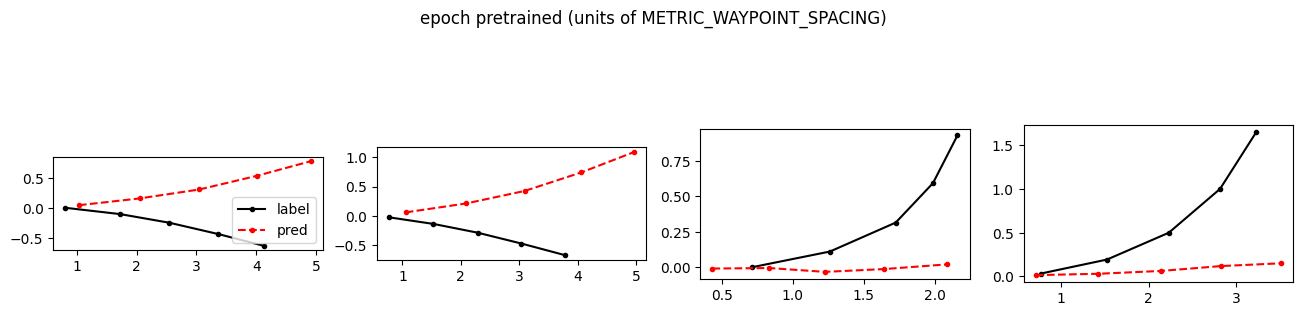

ep   0 | lr 3.00e-05 | train 0.8324 (act 1.2649 wpcos 0.912) | val 0.6791 (wpcos 0.924)


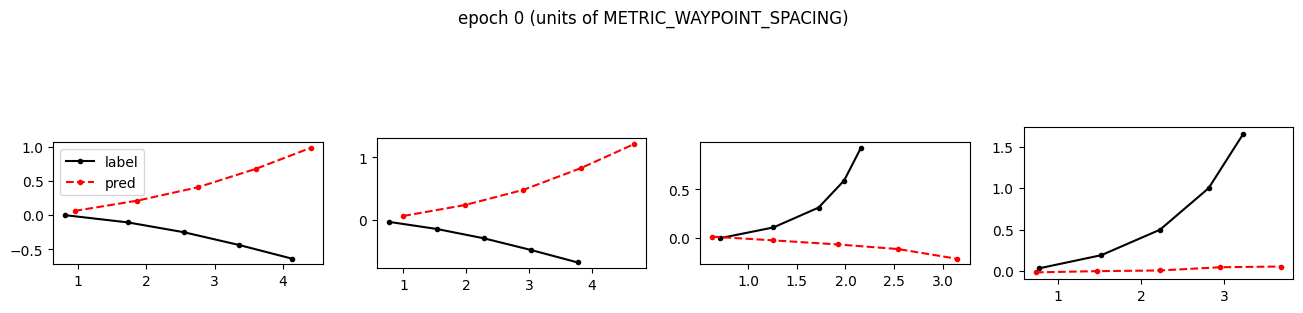

ep   1 | lr 2.96e-05 | train 0.7353 (act 1.1085 wpcos 0.920) | val 0.6121 (wpcos 0.930)
ep   2 | lr 2.85e-05 | train 0.6804 (act 1.0275 wpcos 0.924) | val 0.5832 (wpcos 0.933)
ep   3 | lr 2.67e-05 | train 0.6445 (act 0.9807 wpcos 0.927) | val 0.5650 (wpcos 0.935)
ep   4 | lr 2.44e-05 | train 0.6199 (act 0.9484 wpcos 0.929) | val 0.5513 (wpcos 0.936)
ep   5 | lr 2.15e-05 | train 0.6058 (act 0.9297 wpcos 0.931) | val 0.5419 (wpcos 0.938)


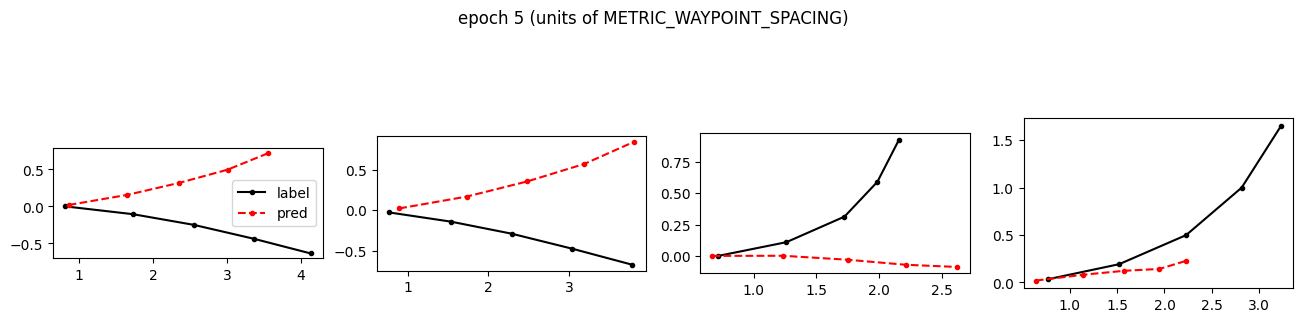

ep   6 | lr 1.83e-05 | train 0.5965 (act 0.9162 wpcos 0.932) | val 0.5352 (wpcos 0.939)
ep   7 | lr 1.50e-05 | train 0.5872 (act 0.9010 wpcos 0.933) | val 0.5295 (wpcos 0.939)
ep   8 | lr 1.17e-05 | train 0.5781 (act 0.8867 wpcos 0.934) | val 0.5254 (wpcos 0.940)
ep   9 | lr 8.49e-06 | train 0.5766 (act 0.8856 wpcos 0.935) | val 0.5219 (wpcos 0.941)
ep  10 | lr 5.65e-06 | train 0.5687 (act 0.8729 wpcos 0.936) | val 0.5199 (wpcos 0.941)


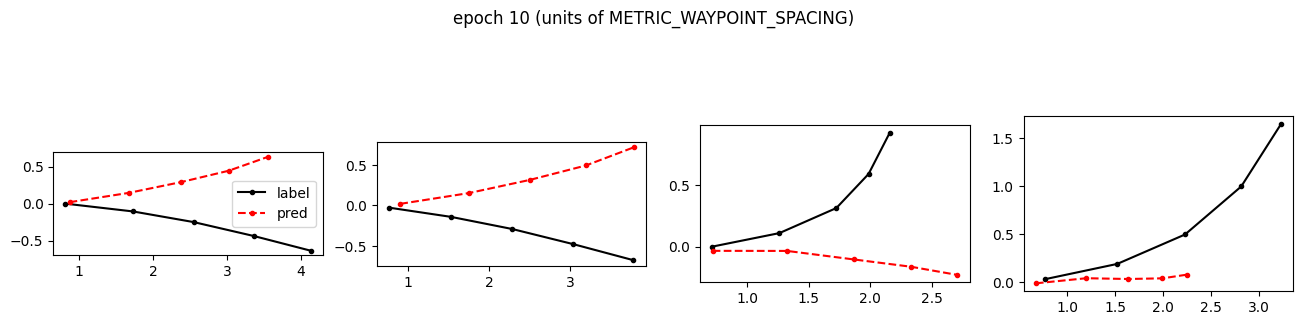

ep  11 | lr 3.27e-06 | train 0.5650 (act 0.8652 wpcos 0.936) | val 0.5186 (wpcos 0.941)
ep  12 | lr 1.49e-06 | train 0.5652 (act 0.8673 wpcos 0.936) | val 0.5179 (wpcos 0.941)
ep  13 | lr 3.76e-07 | train 0.5641 (act 0.8652 wpcos 0.937) | val 0.5176 (wpcos 0.941)
ep  14 | lr 0.00e+00 | train 0.5689 (act 0.8726 wpcos 0.936) | val 0.5176 (wpcos 0.941)


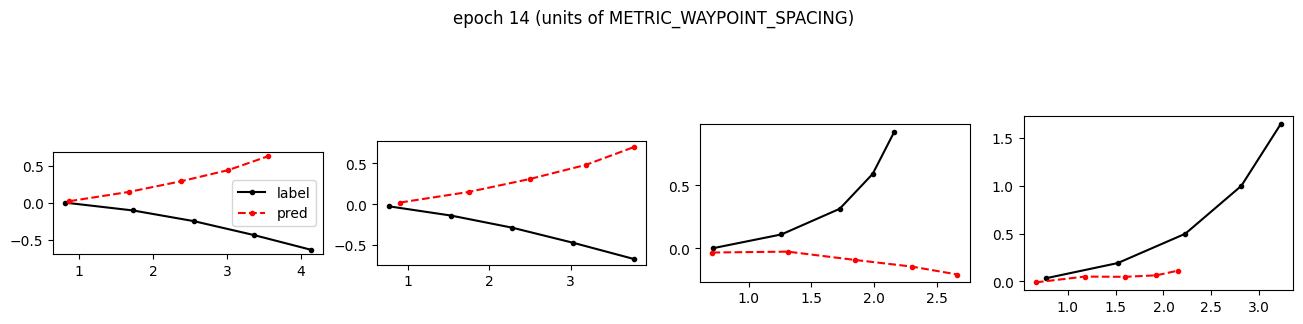

best epoch 13: val 0.5176 (pretrained 0.7961) -> exported /content/drive/MyDrive/sacson_nwm_bc/vint_finetuned.safetensors


In [18]:
def compute_loss(dp, ap, al, dl, alpha=ALPHA):
    # ViNT's own training loss (vint_train/training/train_utils.py).
    dloss = F.mse_loss(dp.squeeze(-1), dl)
    aloss = F.mse_loss(ap, al)
    with torch.no_grad():
        wc = F.cosine_similarity(ap[..., :2], al[..., :2], dim=-1).mean()
    return (1 - alpha) * aloss + alpha * 1e-2 * dloss, aloss.detach(), wc


opt = torch.optim.AdamW(vint.parameters(), lr=FT_LR, weight_decay=FT_WEIGHT_DECAY)
spe = max(1, len(train_dl))
tot_steps, warm = FT_EPOCHS * spe, FT_WARMUP_EPOCHS * spe
sched = torch.optim.lr_scheduler.LambdaLR(
    opt, lambda s: s / max(1, warm) if s < warm else 0.5 * (1 + math.cos(math.pi * min(1.0, (s - warm) / max(1, tot_steps - warm)))))
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and device.type == "cuda"))


@torch.no_grad()
def evaluate():
    vint.eval()
    tot = cos = n = 0.0
    for obs, goal, act, dist in val_dl:
        obs, goal, act, dist = obs.to(device), goal.to(device), act.to(device), dist.to(device)
        with torch.autocast(device_type=device.type, enabled=(USE_AMP and device.type == "cuda")):
            dp, ap = vint(obs, goal)
            t, _, wc = compute_loss(dp, ap, act, dist)
        b = obs.size(0); tot += t.item() * b; cos += wc.item() * b; n += b
    return (tot / n, cos / n) if n else (float("nan"), float("nan"))


@torch.no_grad()
def rollout_plot(ep):
    vint.eval()
    obs, goal, act, _ = next(iter(val_dl if len(val_ds) else train_dl))
    _, ap = vint(obs.to(device), goal.to(device))
    ap, act = ap.float().cpu().numpy(), act.numpy()
    m = min(4, obs.size(0))
    fig, ax = plt.subplots(1, m, figsize=(4 * m, 4), squeeze=False)
    for j in range(m):
        ax[0][j].plot(act[j, :, 0], act[j, :, 1], "k-o", ms=3, label="label")
        ax[0][j].plot(ap[j, :, 0], ap[j, :, 1], "r--o", ms=3, label="pred")
        ax[0][j].set_aspect("equal")
        if j == 0:
            ax[0][j].legend()
    fig.suptitle("epoch %s (units of METRIC_WAYPOINT_SPACING)" % ep); plt.show(); plt.close(fig)


assert len(train_ds) > 0, "no relabelled training samples -- see the relabel summary above"
# Score the untouched pretrained model first: fine-tuning has to beat this to be kept.
pre_vt, pre_vc = evaluate()
print("pretrained ViNT (no fine-tuning) | val %.4f (wpcos %.3f)" % (pre_vt, pre_vc))
rollout_plot("pretrained")
best = pre_vt if not math.isnan(pre_vt) else float("inf")
step = 0; epochs_without_improvement = 0; saved = False
MIN_DELTA = 1e-3
for ep in range(FT_EPOCHS):
    vint.train()
    run = defaultdict(float); seen = 0
    for obs, goal, act, dist in train_dl:
        obs, goal, act, dist = obs.to(device), goal.to(device), act.to(device), dist.to(device)
        with torch.autocast(device_type=device.type, enabled=(USE_AMP and device.type == "cuda")):
            dp, ap = vint(obs, goal)
            loss, aloss, wc = compute_loss(dp, ap, act, dist)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step(); step += 1
        b = obs.size(0); seen += b
        run["t"] += loss.item() * b; run["a"] += aloss.item() * b; run["c"] += wc.item() * b
    seen = max(seen, 1)
    vt, vc = evaluate()
    crit = vt if not math.isnan(vt) else run["t"] / seen
    print("ep %3d | lr %.2e | train %.4f (act %.4f wpcos %.3f) | val %.4f (wpcos %.3f)"
          % (ep, sched.get_last_lr()[0], run["t"] / seen, run["a"] / seen, run["c"] / seen, vt, vc))
    if ep % 5 == 0 or ep == FT_EPOCHS - 1:
        rollout_plot(ep)
    if crit < best - MIN_DELTA:
        best = crit
        epochs_without_improvement = 0
        torch.save({"model": {k: v.detach().cpu() for k, v in vint.state_dict().items()},
                    "config": VINT_CONFIG, "epoch": ep, "val_total": float(vt), "val_wp_cos": float(vc),
                    "pretrained_val_total": float(pre_vt)}, FT_CKPT)
        saved = True
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= FT_EARLY_STOP_PATIENCE:
            print("early stopping: no val improvement > %.4f for %d epochs (best=%.4f)"
                  % (MIN_DELTA, FT_EARLY_STOP_PATIENCE, best))
            break

if saved:
    bestc = torch.load(FT_CKPT, map_location="cpu")
    save_file({k: v.contiguous() for k, v in bestc["model"].items()}, FT_EXPORT)
    print("best epoch %d: val %.4f (pretrained %.4f) -> exported %s"
          % (bestc["epoch"], bestc["val_total"], pre_vt, FT_EXPORT))
else:
    print("fine-tuning never beat the pretrained model on val (%.4f) -- nothing exported" % pre_vt)

### 9b. Baseline: is the loss actually high?

`act`/`wpcos` alone have no absolute scale. This scores a trivial
"keep going straight at the dataset's reference speed" prediction with the
same metrics the training loop prints, so `0.5447` etc. has something concrete
to be compared against.

In [19]:
# --- Baseline: how good is "just keep going straight at the reference speed"? ---
# Same format as the fine-tuning labels: x/y are in units of METRIC_WAYPOINT_SPACING, so
# going straight at the reference speed is x = 1, 2, ..., 5, y = 0, heading unchanged.
_baseline_wp = torch.tensor(np.stack([
    FT_STEP_OFFSETS.astype(np.float32), np.zeros(FT_LEN_TRAJ_PRED),
    np.ones(FT_LEN_TRAJ_PRED), np.zeros(FT_LEN_TRAJ_PRED)], axis=1),
    dtype=torch.float32, device=device)


@torch.no_grad()
def baseline_loss(dl, name):
    """Same accumulation as evaluate(), but scoring the constant straight-line
    baseline above instead of the model -- gives act/wpcos a reference point."""
    tot = cos = n = 0.0
    for _, _, act, _ in dl:
        act = act.to(device)
        bp = _baseline_wp.unsqueeze(0).expand(act.size(0), -1, -1)
        aloss = F.mse_loss(bp, act)
        wc = F.cosine_similarity(bp[..., :2], act[..., :2], dim=-1).mean()
        b = act.size(0); tot += aloss.item() * b; cos += wc.item() * b; n += b
    if n:
        print("baseline (%-5s, go straight @ ref speed) | act %.4f wpcos %.3f" % (name, tot / n, cos / n))
    else:
        print("baseline (%-5s): no samples" % name)


baseline_loss(train_dl, "train")
baseline_loss(val_dl, "val")

baseline (train, go straight @ ref speed) | act 1.2075 wpcos 0.911
baseline (val  , go straight @ ref speed) | act 1.0679 wpcos 0.921


## 10. Publish the fine-tuned policy

Uploads Section 9's fine-tuned ViNT (`FT_EXPORT`) with its config and a model card to a
**new** private HF model repo, `<user>/vint-sacson-finetuned`. The from-scratch model in
`REPO_NAME` is left untouched. Needs Section 9 to have run in this session.

In [21]:
from huggingface_hub import create_repo, upload_folder

FT_REPO_NAME = "vint-sacson-finetuned"   # new repo: the from-scratch model in REPO_NAME is left as is

HF_TOKEN = load_hf_token()
repo_id = "%s/%s" % (HF_USER, FT_REPO_NAME)
assert os.path.exists(FT_CKPT) and os.path.exists(FT_EXPORT), "run Section 9 first -- no fine-tuned checkpoint"
bestc = torch.load(FT_CKPT, map_location="cpu")

EXP = "/content/hf_export_finetune"
shutil.rmtree(EXP, ignore_errors=True); os.makedirs(EXP)
shutil.copy(FT_EXPORT, os.path.join(EXP, "model.safetensors"))

cfg = dict(bestc["config"], image_size=list(FT_IMAGE_SIZE), normalize=True,
           metric_waypoint_spacing=METRIC_WAYPOINT_SPACING, base_checkpoint="official ViNT release (vint.safetensors)",
           labels="MBRA-relabelled SACSoN nominal + TrajectoryCrafter counterfactual samples",
           data_repo="%s/%s" % (HF_USER, DATA_REPO),
           n_train_samples=len(train_ds), n_val_samples=len(val_ds),
           best_epoch=bestc["epoch"], best_val_total_loss=bestc["val_total"],
           best_val_wp_cos=bestc["val_wp_cos"], pretrained_val_total_loss=bestc["pretrained_val_total"])
with open(os.path.join(EXP, "config.json"), "w") as f:
    json.dump(cfg, f, indent=2)

card = "\n".join([
    "---", "license: cc-by-nc-4.0",
    "tags: [robotics, visual-navigation, vint, sacson, fine-tuned]", "---", "",
    "# ViNT fine-tuned on SACSoN corrective data", "",
    "The official [ViNT](https://github.com/robodhruv/visualnav-transformer) release checkpoint,",
    "fine-tuned on [SACSoN/HuRoN](https://sites.google.com/view/sacson-review) samples: real",
    "frames plus drift-then-recover counterfactuals rendered with",
    "[TrajectoryCrafter](https://github.com/TrajectoryCrafter/TrajectoryCrafter). Labels are the",
    "MBRA-relabelled trajectories converted to ViNT's own format. Training data: `%s`." % cfg["data_repo"], "",
    "Same architecture and I/O as the official release, so it drops into ViNT's deployment code:",
    "`obs_img [B,%d,64,85]`, `goal_img [B,3,64,85]` -> `(dist, action[B,5,4])`, waypoints"
    % (3 * (CONTEXT_SIZE + 1)),
    "`(x, y, cos, sin)` one frame apart, x/y in units of %.3f m." % METRIC_WAYPOINT_SPACING, "",
    "```python",
    "from vint_train.models.vint.vint import ViNT",
    "import json, safetensors.torch as st",
    "c = json.load(open('config.json'))",
    "k = ['context_size','len_traj_pred','learn_angle','obs_encoder','obs_encoding_size',",
    "     'late_fusion','mha_num_attention_heads','mha_num_attention_layers','mha_ff_dim_factor']",
    "m = ViNT(**{x: c[x] for x in k}); m.load_state_dict(st.load_file('model.safetensors')); m.eval()",
    "```", "",
    "## Results (held-out SACSoN trajectories)",
    "| model | val loss |", "|---|---|",
    "| official ViNT, no fine-tuning | %.4f |" % bestc["pretrained_val_total"],
    "| fine-tuned (epoch %d) | %.4f |" % (bestc["epoch"], bestc["val_total"]), "",
    "Val loss is ViNT's training loss: 0.5 x waypoint MSE + 0.005 x distance MSE.", "",
    "## Limitations",
    "- Counterfactual frames are geometry-warped + diffusion-refined, not real observations.",
    "- SACSoN covers 3 indoor buildings; fine-tuning on it may reduce ViNT's generality elsewhere.",
    "- CC-BY-NC 4.0; see also the ViNT, TrajectoryCrafter and CogVideoX-Fun licenses.",
])
with open(os.path.join(EXP, "README.md"), "w") as f:
    f.write(card)

create_repo(repo_id, private=True, exist_ok=True, token=HF_TOKEN, repo_type="model")
upload_folder(folder_path=EXP, repo_id=repo_id, token=HF_TOKEN, repo_type="model")
print("model ->", "https://huggingface.co/" + repo_id)

model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

model -> https://huggingface.co/vaishsuresh32/vint-sacson-finetuned


## 11. Notes

- The sample cache (`/content/bc_cache`) is **not wiped** — it mirrors the HF
  dataset repo. Re-run Section 8 in new sessions to process more trajectories
  (manifest-resumed), then Section 9–10 to retrain on the larger set
  (`PULL_FULL_DATASET = True` to pull everything first).
- Speed knobs: `TC_DIFFUSION_STEPS`, `TC_CLIP_LEN`, `TC_SAMPLE_SIZE`, `MAX_SAMPLES_PER_TRAJ`,
  `SAMPLE_STRIDE`. Generation is the bottleneck (~1-3 min/clip on an A100); the
  manifest makes it resumable across sessions.
- First-run checks: `tc_probe()` (camera-left -> content should slide right, dy~0)
  to pick `TC_POSE_W2C` / `TC_DEPTH_SIGN`; then `tc_selftest()` (identity render
  should ~match real); then eyeball a `counterfactual_clips/<key>/` rollout. If the
  warp is over/under-shot, tune `SACSON_HFOV_DEG`. `TC_SUPERSAMPLE` trades render
  time for a smoother drift.

In [ ]:
print("nothing to clean up -- data kept in", CACHE_DIR, "and", DATA_REPO_ID)

nothing to clean up -- data kept in /content/bc_cache and vaishsuresh32/vint-sacson-bc-data
